In [1]:
# ==============================================================================
# ECOLOGICAL INVASION RISK GNN — PRODUCTION WORKFLOW
#
# Predicts which alien species are most likely to establish in a target country
# by combining four complementary signals:
#
#   1. Relational ecology  — heterogeneous GNN over species interactions and
#                            taxonomy (GraphSAGE, 2 layers)
#   2. Climate niche       — Mahalanobis distance between a species' realized
#                            climate niche (mean ± std across known range) and
#                            the target country's climate profile
#   3. Trade pathways      — ecological risk channels (flora, fauna, agriculture
#                            etc.) derived from BACI UN trade data, routed
#                            dynamically through confirmed species presence
#   4. Biotic opportunity  — fraction of a species' GloBI interaction partners
#                            already present in the target country
#
# Architecture:
#   CountryAutoencoder        — encodes 7-dim climate vector → 32-dim latent
#   RelationalEcologicalGNN   — 2-layer HeteroSAGE over species + taxonomy
#   TradePathwayEncoder       — fuses import/export trade profiles per pair
#   NicheMatchingPredictor    — 5-stream classifier with detached climate gate
#
# Data requirements:
#   sinas_matched_species.csv         — SINAS alien/native species records
#   matched_globi_network.csv         — species-level GloBI interactions
#   matched_globi_network_higher_order.csv — genus/family/order-level interactions
#   aligned_country_climate.csv       — 7 climate variables per country
#   trade_channels.pt                 — pre-processed BACI trade tensor
#   gbif_presence.pt                  — GBIF presence matrix + bio-opp matrix
#
# !pip install torch_geometric pygbif country_converter -q
# ==============================================================================

import os, time, logging
from collections import defaultdict

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from torch_geometric.data import HeteroData
from torch_geometric.nn import HeteroConv, SAGEConv, LayerNorm
from tqdm.auto import tqdm
from pygbif import species as gbif_species
from pygbif import occurrences
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
import country_converter as coco

logging.getLogger('country_converter').setLevel(logging.ERROR)

In [2]:
# ==============================================================================
# 1. DATA LOADING
# ==============================================================================
print("📖 Reading repository datasets...")

#repo_root = Path('/content')   # FOR IN GOOGLE COLLAB
repo_root         = Path.cwd().parent # FOR LOCAL REPO
repo_root = repo_root / "data" #FOr LOCAL REPO

sinas_path         = repo_root / 'sinas_matched_species.csv'
network_path       = repo_root / 'matched_globi_network.csv'
higher_order_path  = repo_root / 'matched_globi_network_higher_order.csv'
climate_path       = repo_root / 'aligned_country_climate.csv'
trade_path         = repo_root / 'trade_channels.pt'
baci_path          = repo_root / 'BACI_HS17_Y2019_V202401.csv'
gbif_presence_path = repo_root / 'gbif_presence_split.pt'
country_col        = 'location'

df_sinas   = pd.read_csv(sinas_path,        engine='python', on_bad_lines='warn')
df_net     = pd.read_csv(network_path,       engine='python', on_bad_lines='warn')
df_higher  = pd.read_csv(higher_order_path,  engine='python', on_bad_lines='warn')
df_climate = pd.read_csv(climate_path,       engine='python', on_bad_lines='warn')

print(f"   SInAS rows          : {len(df_sinas):,}")
print(f"   Species-level GloBI : {len(df_net):,}")
print(f"   Higher-order GloBI  : {len(df_higher):,}")
print(f"   Climate rows        : {len(df_climate):,}")

df_sinas = df_sinas.dropna(subset=['gbif_id']).copy()
df_sinas['gbif_id'] = df_sinas['gbif_id'].astype(int)

# Parse establishment status from SINAS establishmentMeans field.
# is_native → species is indigenous (used for niche profiling)
# is_alien  → species is introduced/invasive/naturalised (training positives)
df_sinas['is_native'] = (df_sinas['establishmentMeans'].fillna('')
                          .str.lower().str.contains('native'))
df_sinas['is_alien']  = (df_sinas['establishmentMeans'].fillna('')
                          .str.lower().str.contains(
                              'introduced|invasive|naturalised|alien'))

📖 Reading repository datasets...
   SInAS rows          : 378,728
   Species-level GloBI : 952,088
   Higher-order GloBI  : 444,765
   Climate rows        : 289


In [3]:
# ==============================================================================
# 2. INTERACTION TYPE ONTOLOGY
#    Maps raw GloBI strings to four ecological categories.
#    'unknown' terms are tracked for transparency but excluded from edges.
# ==============================================================================
CONSUMPTION_TERMS = {
    'eats','preysOn','parasitizes','pathogenOf','parasitoidOf','consumes',
    'endoparasitoidOf','ectoparasitoidOf','endoparasiteOf','ectoparasiteOf',
    'scavenges','browses','grazesOn','hasHost','kills','saprophyteOf',
    'hyperparasiteOf','hyperparasitoidOf','bloodFeedsOn','nectarFeedsOn',
    'pollenFeedsOn','seedEaterOf','woodBorerOf','leafMinerOf','gallMakerOf',
    'defoliatorOf','rootFeederOf','vectorOf', 'parasiteOf', 'hemiparasiteOf', 'ectoParasitoid',
    'kleptoparasiteOf', 'rootparasiteOf', 'laysEggsOn', 'laysEggsIn'
}

MUTUALISM_TERMS = {
    'pollinates','visitsFlowersOf','symbiontOf','mutualistOf','associatedWith',
    'coOccursWith','hasSymbiont','commensalistOf','hasCommensalist','epiphyteOf',
    'hasEpiphyte','inquilineOf','hasInquiline','phoreticOf','hasPhoretic',
    'mycorrhizalWith','dispersesSeedsOf','disperses','vectorFor','sheltersWithin',
    'providesShelterTo','nestedIn','hostsNestedIn','flowersVisitedBy','visitedBy', 'hasVector',
    'hasDispersalVector', 'guestOf', 'coRoostsWith', 'hasHabitat', 'hasRoost', 'livesOn',
    'livesInsideOf', 'livesUnder', 'livesNear', 'inhabits'
}
COMPETITION_TERMS = {
    'competesWith','interferesWith','allelopathicTo','inhibits',
    'displaces','antagonistOf', 'allelopathOf'
}
VICTIM_TERMS = {
    'hostOf','hasParasite','hasPathogen','hasParasitoid','preyedOnBy','eatenBy', 'providesNutrientsFor',
    'parasitizedBy','infectedBy','killedBy','preyedUponBy','parasitoidBy','pathogenBy'
}

def categorize_interaction(itype: str) -> str:
    """Map a raw GloBI interaction type to resource/enemy/mutualism/competition/unknown."""
    if pd.isna(itype): return 'unknown'
    c = itype.strip(); l = c.lower()
    if c in CONSUMPTION_TERMS:  return 'resource'
    if c in MUTUALISM_TERMS:    return 'mutualism'
    if c in COMPETITION_TERMS:  return 'competition'
    if c in VICTIM_TERMS:       return 'enemy'
    if 'by' in l and any(w in l for w in ['eat','prey','parasit','kill','infect','attack']):
        return 'enemy'
    if any(w in l for w in ['eat','prey','consume','host','feed','graze','browse','destroy']):
        return 'resource'
    if any(w in l for w in ['symbio','mutual','pollin','cooccur','visit','associat','commens','shelter']):
        return 'mutualism'
    if any(w in l for w in ['compet','inhib','displac','antagon','resist','exclude']):
        return 'competition'
    return 'unknown'

all_interaction_types = pd.concat(
    [df_net['interaction_type'], df_higher['interaction_type']]
).dropna().unique()
interaction_mapping = {t: categorize_interaction(t) for t in all_interaction_types}

_cat_counts = pd.Series(list(interaction_mapping.values())).value_counts()
print("   Interaction category breakdown (unique raw terms):")
for cat, cnt in _cat_counts.items():
    print(f"     {cat}: {cnt}")
_all_mapped = (pd.concat([df_net['interaction_type'], df_higher['interaction_type']])
               .map(lambda t: interaction_mapping.get(t, 'unknown') if pd.notna(t) else 'unknown'))
_unk_frac = (_all_mapped == 'unknown').mean()
print(f"   {_unk_frac:.1%} of all interaction records are 'unknown' (excluded from edges)")

   Interaction category breakdown (unique raw terms):
     mutualism: 19
     resource: 18
     unknown: 3
     competition: 1
     enemy: 1
   24.3% of all interaction records are 'unknown' (excluded from edges)


In [4]:
# ==============================================================================
# 2b. VERIFY TYPE OF UNKNOWN INTERACTIONS
#    Maps number of terms and their name that are classified as unknown.
# ==============================================================================

# Combine all raw interaction types into a single Series
all_raw_interactions = pd.concat(
    [df_net['interaction_type'], df_higher['interaction_type']]
).dropna()

# Filter the Series to only include terms that mapped to 'unknown'
unknown_terms_series = all_raw_interactions[
    all_raw_interactions.map(lambda t: interaction_mapping.get(t, 'unknown')) == 'unknown'
]

# Get the value counts for the 23 unique unknown terms
unknown_counts = unknown_terms_series.value_counts()

print("### The 23 'Unknown' Terms and Their Frequencies ###")
print(unknown_counts)

### The 23 'Unknown' Terms and Their Frequencies ###
interaction_type
interactsWith            281849
adjacentTo                56934
ecologicallyRelatedTo      1045
Name: count, dtype: int64


In [5]:
# ==============================================================================
# 3. INDEX MAPPINGS
# ==============================================================================
print("⚙️ Engineering index maps...")

TAX_LEVELS = ['gbif_genus_id','gbif_family_id','gbif_order_id',
              'gbif_class_id','gbif_phylum_id','gbif_kingdom_id']
for col in TAX_LEVELS:
    if col in df_sinas.columns:
        df_sinas[col] = df_sinas[col].fillna(-1).astype(int)
    else:
        print(f"   ⚠️  Column '{col}' not found — filling with -1")
        df_sinas[col] = -1

sinas_sp   = set(df_sinas['gbif_id'].unique())
net_src_sp = set(df_net['source_gbif_id'].dropna().astype(int).unique())
net_tgt_sp = set(df_net['target_gbif_id'].dropna().astype(int).unique())
all_species_ids   = sorted(sinas_sp | net_src_sp | net_tgt_sp)
all_country_names = sorted(df_sinas[country_col].dropna().unique().tolist())

def build_tax_set(col):
    return set(df_sinas[df_sinas[col] != -1][col].unique())

unique_genera   = build_tax_set('gbif_genus_id')
unique_families = build_tax_set('gbif_family_id')
unique_orders   = build_tax_set('gbif_order_id')
unique_classes  = build_tax_set('gbif_class_id')
unique_phyla    = build_tax_set('gbif_phylum_id')
unique_kingdoms = build_tax_set('gbif_kingdom_id')

for rank, node_set in [('GENUS', unique_genera), ('FAMILY', unique_families),
                        ('ORDER', unique_orders), ('CLASS', unique_classes)]:
    for side in ['source', 'target']:
        ids = (df_higher[df_higher[f'{side}_rank'] == rank]
               [f'{side}_gbif_id'].dropna().astype(int).unique())
        node_set.update(ids)

unique_genera   = sorted(unique_genera)
unique_families = sorted(unique_families)
unique_orders   = sorted(unique_orders)
unique_classes  = sorted(unique_classes)
unique_phyla    = sorted(unique_phyla)
unique_kingdoms = sorted(unique_kingdoms)

sp_to_idx      = {sp_id: idx for idx, sp_id in enumerate(all_species_ids)}
idx_to_sp      = {v: k for k, v in sp_to_idx.items()}
co_to_idx      = {name: idx  for idx, name  in enumerate(all_country_names)}
idx_to_co      = {v: k for k, v in co_to_idx.items()}
genus_to_idx   = {g: i for i, g in enumerate(unique_genera)}
family_to_idx  = {f: i for i, f in enumerate(unique_families)}
order_to_idx   = {o: i for i, o in enumerate(unique_orders)}
class_to_idx   = {c: i for i, c in enumerate(unique_classes)}
phylum_to_idx  = {p: i for i, p in enumerate(unique_phyla)}
kingdom_to_idx = {k: i for i, k in enumerate(unique_kingdoms)}

num_species   = len(all_species_ids)
num_countries = len(all_country_names)
num_genera    = len(unique_genera)
num_families  = len(unique_families)
num_orders    = len(unique_orders)
num_classes   = len(unique_classes)
num_phyla     = len(unique_phyla)
num_kingdoms  = len(unique_kingdoms)

id_to_name = (df_sinas.drop_duplicates('gbif_id')
                       .set_index('gbif_id')['gbif_canonical_name'].to_dict())
for row in df_net.dropna(subset=['source_gbif_id']).drop_duplicates('source_gbif_id').itertuples():
    if int(row.source_gbif_id) not in id_to_name:
        id_to_name[int(row.source_gbif_id)] = row.source_taxon_name
for row in df_net.dropna(subset=['target_gbif_id']).drop_duplicates('target_gbif_id').itertuples():
    if int(row.target_gbif_id) not in id_to_name:
        id_to_name[int(row.target_gbif_id)] = row.target_taxon_name

print(f"   Species: {num_species:,} | Countries: {num_countries:,} | "
      f"Genera: {num_genera:,} | Families: {num_families:,} | "
      f"Orders: {num_orders:,} | Classes: {num_classes:,} | "
      f"Phyla: {num_phyla:,} | Kingdoms: {num_kingdoms:,}")

⚙️ Engineering index maps...
   Species: 167,357 | Countries: 289 | Genera: 22,182 | Families: 2,889 | Orders: 622 | Classes: 159 | Phyla: 51 | Kingdoms: 7


In [6]:
# ==============================================================================
# 4. CLIMATE FEATURES
#    7 climate variables per country, min-max normalised to [0, 1].
#    Normalisation uses global min/max across all countries — safe because
#    climate is a static, label-independent feature.
# ==============================================================================
CLIMATE_COLS = ['latitude','longitude','mean_temperature',
                'temperature_seasonality','frost_days',
                'precipitation','aridity_index']
n_co_features = len(CLIMATE_COLS)

climate_lookup    = df_climate.set_index('location')[CLIMATE_COLS].to_dict(orient='index')
co_feature_matrix = torch.zeros(num_countries, n_co_features)
missing_climate   = []

for country_name, co_idx in co_to_idx.items():
    if country_name in climate_lookup:
        vals = [climate_lookup[country_name][c] for c in CLIMATE_COLS]
        co_feature_matrix[co_idx] = torch.tensor(vals, dtype=torch.float)
    else:
        missing_climate.append(country_name)

for i in range(n_co_features):
    col = co_feature_matrix[:, i]
    col_min, col_max = col.min(), col.max()
    if col_max > col_min:
        co_feature_matrix[:, i] = (col - col_min) / (col_max - col_min)

co_climate_tensor = co_feature_matrix.clone()
if missing_climate:
    print(f"   ⚠️  {len(missing_climate)} countries missing climate data — zero vector used")
print(f"   Climate tensor: {co_climate_tensor.shape}")

   Climate tensor: torch.Size([289, 7])


In [7]:
# ==============================================================================
# 4b. TRADE CHANNELS
# ==============================================================================
print("📦 Loading trade channel tensor...")

ECOLOGICAL_TRADE_MAPPING = {
    'flora_and_timber': ('06', '44'),
    'aquatic_fauna':    ('03',),
    'terrestrial_pets': ('01',),
    'agri_hitchhikers': ('07', '08', '10', '12'),
    'microbial_risk':   ('3002', '3821'),
}
channel_keys = list(ECOLOGICAL_TRADE_MAPPING.keys())
num_channels = len(channel_keys)

SUB_NATIONAL_TO_ISO = {
    'Aegean':'GRC','Caspian Sea':'RUS','Alaska':'USA','Hawaii':'USA',
    'Virgin Islands (U.S.)':'USA','United States Minor Outlying Islands':'USA',
    'Puerto Rico':'USA','Guam':'USA','American Samoa':'USA',
    'Northern Mariana Islands':'USA','Canary Islands':'ESP','Balearic Islands':'ESP',
    'Azores':'PRT','Madeira':'PRT','Sicily':'ITA','Sardinia':'ITA',
    'Tasmania':'AUS','Lord Howe Islands':'AUS','Norfolk Island':'AUS',
    'Christmas Island':'AUS','Cocos Islands':'AUS','Galapagos':'ECU',
    'Corsica':'FRA','Réunion':'FRA','Mayotte':'FRA','Guadeloupe':'FRA',
    'Martinique':'FRA','French Guiana':'FRA','Saint Pierre and Miquelon':'FRA',
    'Saint-Barthélemy':'FRA','Saint-Martin':'FRA','Amsterdam Island':'FRA',
    'Crozet Islands':'FRA','Kerguelen Islands':'FRA','St. Paul Island':'FRA',
    'Scattered Islands':'FRA','Shetland Islands':'GBR','Guernsey':'GBR',
    'Jersey':'GBR','Isle of Man':'GBR','Akrotiri and Dhekelia':'GBR',
    'Gibraltar':'GBR','Bermuda':'GBR','Anguilla':'GBR','Cayman Islands':'GBR',
    'Montserrat':'GBR','Turks and Caicos Islands':'GBR',
    'Virgin Islands (British)':'GBR','Falkland Islands':'GBR',
    'Pitcairn Islands':'GBR','Saint Helena':'GBR','Ascension':'GBR',
    'Tristan da Cunha':'GBR','Chagos Archipelago':'GBR',
    'South Georgia and the South Sandwich Islands':'GBR','Vancouver Island':'CAN',
    'Crete':'GRC','Zanzibar Island':'TZA','Rapa Nui':'CHL','Socotra Island':'YEM',
    'Nicobar and Andaman Islands':'IND','Rodriguez Island':'MUS',
    'Hong Kong':'CHN','Macao':'CHN','Bonaire':'NLD','Saba':'NLD',
    'Sint Eustatius':'NLD','Curaçao':'NLD','Sint Maarten':'NLD',
    'Faroe Islands':'DNK','Greenland':'DNK','Svalbard and Jan Mayen':'NOR',
    'Bouvet Island':'NOR','Åland':'FIN','Tokelau':'NZL','Niue':'NZL',
    'Cook Islands':'NZL','Kermadec Islands':'NZL','Northern Cyprus':'CYP',
    'Western Sahara':'MAR','Fernando de Noronha':'BRA','Paracel Islands':'CHN',
    'Spratly Islands':'CHN','Palestine':'PSE','Kosovo':'XKX',
    'Antipodes Island':'NZL','Izu Islands':'JPN','Ogasawara Islands':'JPN',
}

cc = coco.CountryConverter()
name_to_iso3 = {}
for name in all_country_names:
    if name in SUB_NATIONAL_TO_ISO:
        name_to_iso3[name] = SUB_NATIONAL_TO_ISO[name]
    else:
        iso3 = cc.convert(names=name, to='ISO3')
        name_to_iso3[name] = 'WLD' if iso3 == 'not_found' else iso3

iso3_to_graph_indices = defaultdict(list)
for name, iso3 in name_to_iso3.items():
    iso3_to_graph_indices[iso3].append(co_to_idx[name])

N = num_countries

if trade_path.exists():
    trade_data            = torch.load(trade_path, map_location='cpu', weights_only=False)
    trade_channels_tensor = trade_data['trade_tensor']
    trade_channels_list   = trade_data['channels_order']
    print(f"   Loaded trade tensor: {trade_channels_tensor.shape}")
    if trade_channels_tensor.shape[0] != num_channels:
        raise ValueError(f"trade_tensor has {trade_channels_tensor.shape[0]} channels "
                         f"but mapping defines {num_channels}.")
else:
    if not baci_path.exists():
        raise FileNotFoundError(f"Neither {trade_path} nor {baci_path} found.")
    print(f"   Building from {baci_path.name}...")
    baci_ids        = pd.read_csv(baci_path, usecols=['i', 'j'])
    unique_un_codes = list(set(baci_ids['i'].unique()) | set(baci_ids['j'].unique()))
    converted       = cc.convert(names=unique_un_codes, src='UNcode', to='ISO3')
    if not isinstance(converted, list): converted = [converted]
    baci_num_to_iso3 = {num: iso3 for num, iso3 in zip(unique_un_codes, converted)
                        if iso3 != 'not_found'}
    channel_idx_map    = {k: i for i, k in enumerate(channel_keys)}
    raw_trade_matrices = np.zeros((num_channels, N, N), dtype=np.float64)
    baci_dtypes        = {'t': np.int16, 'k': np.int32, 'i': np.int16,
                          'j': np.int16, 'v': np.float32}
    with pd.read_csv(baci_path, dtype=baci_dtypes, chunksize=250_000) as reader:
        for chunk in tqdm(reader, desc="Processing BACI"):
            chunk['exp_iso'] = chunk['i'].map(baci_num_to_iso3)
            chunk['imp_iso'] = chunk['j'].map(baci_num_to_iso3)
            chunk = chunk.dropna(subset=['exp_iso','imp_iso'])
            chunk = chunk[chunk['exp_iso'].isin(iso3_to_graph_indices) &
                          chunk['imp_iso'].isin(iso3_to_graph_indices)]
            if chunk.empty: continue
            chunk['k_str'] = chunk['k'].astype(str).str.zfill(6)
            for ch_name, prefixes in ECOLOGICAL_TRADE_MAPPING.items():
                ch_idx = channel_idx_map[ch_name]
                sub_df = chunk[chunk['k_str'].str.startswith(prefixes)]
                if sub_df.empty: continue
                agg = sub_df.groupby(['exp_iso','imp_iso'])['v'].sum().reset_index()
                for row in agg.itertuples():
                    for e_idx in iso3_to_graph_indices[row.exp_iso]:
                        for i_idx in iso3_to_graph_indices[row.imp_iso]:
                            raw_trade_matrices[ch_idx, e_idx, i_idx] += float(row.v)
    trade_channels_tensor = torch.tensor(np.log1p(raw_trade_matrices), dtype=torch.float32)
    trade_channels_list   = channel_keys
    torch.save({'trade_tensor': trade_channels_tensor,
                'channels_order': trade_channels_list,
                'locations_order': all_country_names}, trade_path)

co_trade_import = trade_channels_tensor.sum(dim=1).T
co_trade_export = trade_channels_tensor.sum(dim=2).T
for c in range(num_channels):
    for mat in [co_trade_import, co_trade_export]:
        col_min, col_max = mat[:, c].min(), mat[:, c].max()
        if col_max > col_min:
            mat[:, c] = (mat[:, c] - col_min) / (col_max - col_min)
print(f"   Import profile: {co_trade_import.shape} | Export profile: {co_trade_export.shape}")

📦 Loading trade channel tensor...
   Loaded trade tensor: torch.Size([5, 289, 289])
   Import profile: torch.Size([289, 5]) | Export profile: torch.Size([289, 5])


In [8]:
# ==============================================================================
# 4c. GBIF PRESENCE + BIOTIC OPPORTUNITY MATRIX (pos/neg split)
#
#    presence_mat[sp, co] — species sp confirmed present in country co (GBIF)
#    pos_opp_mat[sp, co]  — fraction of sp's POSITIVE-valence GloBI partners
#                           (resource/mutualism: food, hosts, pollinators,
#                           symbionts) confirmed present in co
#    neg_opp_mat[sp, co]  — fraction of sp's NEGATIVE-valence GloBI partners
#                           (enemy/competition: predators, parasites,
#                           pathogens, competitors) confirmed present in co
#
#    Used for: (a) native_ei enrichment for realized niche, (b) biotic
#    opportunity score (now 2-dim: [pos, neg]), (c) dynamic trade routing.
#    NOT used for established_in edges — those come from SINAS exclusively.
# ==============================================================================
print("🌿 Loading GBIF presence + biotic opportunity matrices (pos/neg split)...")
if not gbif_presence_path.exists():
    raise FileNotFoundError(f"{gbif_presence_path} not found. "
                            "Run fetch_gbif_presabs_country_pos_neg_split.ipynb first.")
_gbif        = torch.load(gbif_presence_path, map_location='cpu', weights_only=False)
presence_mat = _gbif['presence'].float()
pos_opp_mat  = _gbif['pos_opp_mat'].float()
neg_opp_mat  = _gbif['neg_opp_mat'].float()

assert _gbif['species_order']   == all_species_ids,   \
    "Species order mismatch — re-run fetch_gbif_presabs_country_pos_neg_split.ipynb"
assert _gbif['countries_order'] == all_country_names, \
    "Country order mismatch — re-run fetch_gbif_presabs_country_pos_neg_split.ipynb"

if not _gbif.get('complete', False):
    n_failed = len(_gbif.get('permanently_failed', []))
    print(f"   ⚠️  Presence data incomplete — {n_failed} species failed GBIF fetch.")
print(f"   Presence: {list(presence_mat.shape)} | "
      f"Pos-opp: {list(pos_opp_mat.shape)} | Neg-opp: {list(neg_opp_mat.shape)} | "
      f"Total presences: {int(presence_mat.sum()):,}")

def biotic_opportunity_score(sp_idx_batch, co_idx_batch):
    """
    Returns (B, 2) tensor: [fraction of positive-valence partners present,
    fraction of negative-valence partners present] for each (sp, co) pair.
    Kept split rather than averaged into one number — a species surrounded
    by predators should not score identically to one surrounded by
    prey/mutualists. See Section 8 of fetch_gbif_presabs_country_pos_neg_split.ipynb.
    """
    pos = pos_opp_mat[sp_idx_batch, co_idx_batch]
    neg = neg_opp_mat[sp_idx_batch, co_idx_batch]
    return torch.stack([pos, neg], dim=-1)

🌿 Loading GBIF presence + biotic opportunity matrices (pos/neg split)...
   Presence: [167357, 289] | Pos-opp: [167357, 289] | Neg-opp: [167357, 289] | Total presences: 3,311,662


In [9]:
# ==============================================================================
# 5. HETEROGENEOUS GRAPH CONSTRUCTION
# ==============================================================================
print("🕸️ Compiling HeteroData graph...")
data    = HeteroData()
emb_dim = 64
torch.manual_seed(42)

df_sinas['sp_idx'] = df_sinas['gbif_id'].map(sp_to_idx)
df_sinas['co_idx'] = df_sinas[country_col].map(co_to_idx)
native_df = df_sinas[df_sinas['is_native']].dropna(subset=['sp_idx','co_idx'])
alien_df  = df_sinas[df_sinas['is_alien']].dropna(subset=['sp_idx','co_idx'])

def tensor_edges(src_vals, tgt_vals):
    return torch.tensor([src_vals.astype(int), tgt_vals.astype(int)], dtype=torch.long)

data['species','native_to',       'country'].edge_index = tensor_edges(
    native_df['sp_idx'].values, native_df['co_idx'].values)
data['species','established_in',  'country'].edge_index = tensor_edges(
    alien_df['sp_idx'].values,  alien_df['co_idx'].values)
data['country','has_native',      'species'].edge_index = tensor_edges(
    native_df['co_idx'].values, native_df['sp_idx'].values)
data['country','has_established', 'species'].edge_index = tensor_edges(
    alien_df['co_idx'].values,  alien_df['sp_idx'].values)

df_tax = df_sinas.dropna(subset=['gbif_id']).drop_duplicates('gbif_id').copy()

def add_tax_edges(df, src_col, src_idx_col, src_map, src_node,
                  tgt_col, tgt_idx_col, tgt_map, tgt_node,
                  fwd_rel, rev_rel, dedup_col=None):
    """Add forward + reverse taxonomy edges. dedup_col avoids duplicate parent edges."""
    df = df.copy()
    df[src_idx_col] = df[src_col].map(src_map)
    df[tgt_idx_col] = df[tgt_col].map(tgt_map)
    sub = df.dropna(subset=[src_idx_col, tgt_idx_col])
    if dedup_col: sub = sub.drop_duplicates(dedup_col)
    if sub.empty: return
    data[src_node, fwd_rel, tgt_node].edge_index = tensor_edges(
        sub[src_idx_col].values, sub[tgt_idx_col].values)
    data[tgt_node, rev_rel, src_node].edge_index = tensor_edges(
        sub[tgt_idx_col].values, sub[src_idx_col].values)

add_tax_edges(df_tax,'gbif_id','sp_idx',sp_to_idx,'species',
              'gbif_genus_id','genus_idx',genus_to_idx,'genus',
              'belongs_to_genus','has_species')
add_tax_edges(df_tax,'gbif_genus_id','genus_idx',genus_to_idx,'genus',
              'gbif_family_id','family_idx',family_to_idx,'family',
              'belongs_to_family','has_genus', dedup_col='gbif_genus_id')
add_tax_edges(df_tax,'gbif_family_id','family_idx',family_to_idx,'family',
              'gbif_order_id','order_idx',order_to_idx,'order',
              'belongs_to_order','has_family', dedup_col='gbif_family_id')
add_tax_edges(df_tax,'gbif_order_id','order_idx',order_to_idx,'order',
              'gbif_class_id','class_idx',class_to_idx,'class',
              'belongs_to_class','has_order', dedup_col='gbif_order_id')
add_tax_edges(df_tax,'gbif_class_id','class_idx',class_to_idx,'class',
              'gbif_phylum_id','phylum_idx',phylum_to_idx,'phylum',
              'belongs_to_phylum','has_class', dedup_col='gbif_class_id')
add_tax_edges(df_tax,'gbif_phylum_id','phylum_idx',phylum_to_idx,'phylum',
              'gbif_kingdom_id','kingdom_idx',kingdom_to_idx,'kingdom',
              'belongs_to_kingdom','has_phylum', dedup_col='gbif_phylum_id')

# Species-level GloBI edges — 'unknown' category explicitly excluded
df_net_clean = df_net.dropna(
    subset=['interaction_type','source_gbif_id','target_gbif_id']).copy()
df_net_clean['src_idx']  = df_net_clean['source_gbif_id'].astype(int).map(sp_to_idx)
df_net_clean['tgt_idx']  = df_net_clean['target_gbif_id'].astype(int).map(sp_to_idx)
df_net_clean             = df_net_clean.dropna(subset=['src_idx','tgt_idx'])
df_net_clean['category'] = df_net_clean['interaction_type'].map(interaction_mapping)
df_net_clean             = df_net_clean[df_net_clean['category'] != 'unknown']

for cat in ['resource','mutualism','competition']:
    sub = df_net_clean[df_net_clean['category'] == cat]
    if not sub.empty:
        data['species',cat,'species'].edge_index = tensor_edges(
            sub['src_idx'].values, sub['tgt_idx'].values)

# Enemy edges: explicit enemy records + reverse of resource edges
enemy_df     = df_net_clean[df_net_clean['category'] == 'enemy']
res_df       = df_net_clean[df_net_clean['category'] == 'resource']
combined_src = np.concatenate([enemy_df['src_idx'].values, res_df['tgt_idx'].values])
combined_tgt = np.concatenate([enemy_df['tgt_idx'].values, res_df['src_idx'].values])
if len(combined_src) > 0:
    data['species','enemy','species'].edge_index = torch.tensor(
        [combined_src.astype(int), combined_tgt.astype(int)], dtype=torch.long)

# Higher-order GloBI edges
df_higher_clean = df_higher.dropna(
    subset=['interaction_type','source_gbif_id','target_gbif_id']).copy()
df_higher_clean['source_gbif_id'] = df_higher_clean['source_gbif_id'].astype(int)
df_higher_clean['target_gbif_id'] = df_higher_clean['target_gbif_id'].astype(int)
df_higher_clean['category']       = df_higher_clean['interaction_type'].map(interaction_mapping)
df_higher_clean                   = df_higher_clean[df_higher_clean['category'] != 'unknown']

def add_higher_order_edges(df, src_rank, tgt_rank, src_map, tgt_map,
                            src_node, tgt_node, rel_prefix):
    """Add interaction edges between higher-order taxonomic nodes."""
    sub = df[(df['source_rank'] == src_rank) & (df['target_rank'] == tgt_rank)].copy()
    sub['src_idx'] = sub['source_gbif_id'].map(src_map)
    sub['tgt_idx'] = sub['target_gbif_id'].map(tgt_map)
    sub = sub.dropna(subset=['src_idx','tgt_idx'])
    for cat in ['resource','mutualism','competition','enemy']:
        s = sub[sub['category'] == cat]
        if not s.empty:
            data[src_node, f'{rel_prefix}_{cat}', tgt_node].edge_index = tensor_edges(
                s['src_idx'].values, s['tgt_idx'].values)

add_higher_order_edges(df_higher_clean,'GENUS', 'GENUS', genus_to_idx,  genus_to_idx,  'genus', 'genus', 'genus')
add_higher_order_edges(df_higher_clean,'GENUS', 'SPECIES',genus_to_idx, sp_to_idx,     'genus', 'species','genus_sp')
add_higher_order_edges(df_higher_clean,'SPECIES','GENUS', sp_to_idx,    genus_to_idx,  'species','genus', 'sp_genus')
add_higher_order_edges(df_higher_clean,'FAMILY','FAMILY', family_to_idx,family_to_idx, 'family','family', 'family')
add_higher_order_edges(df_higher_clean,'ORDER', 'ORDER',  order_to_idx, order_to_idx,  'order', 'order',  'order')
add_higher_order_edges(df_higher_clean,'CLASS', 'CLASS',  class_to_idx, class_to_idx,  'class', 'class',  'class')

🕸️ Compiling HeteroData graph...


C:\Users\simon\AppData\Local\Temp\ipykernel_14276\2572947650.py:15: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  return torch.tensor([src_vals.astype(int), tgt_vals.astype(int)], dtype=torch.long)


In [10]:
# ==============================================================================
# 5b. SPECIES NODE FEATURES (5 structural dimensions)
#    Feature 0: out-degree in resource edges
#    Feature 1: in-degree in enemy edges
#    Feature 2: out-degree in mutualism edges
#    Feature 3: native flag (SINAS + GBIF)
#    Feature 4: total biotic degree (sum of 0-2)
#    No invasiveness count — would leak the training label.
# ==============================================================================
print("🧬 Engineering species node features...")

sinas_native_ei = data['species','native_to','country'].edge_index
gbif_pairs      = presence_mat.nonzero(as_tuple=False)
gbif_native_ei  = gbif_pairs.T.long()
native_ei       = torch.unique(
    torch.cat([sinas_native_ei, gbif_native_ei], dim=1), dim=1)
print(f"   Native edges — SINAS: {sinas_native_ei.shape[1]:,} | "
      f"GBIF: {gbif_native_ei.shape[1]:,} | Union: {native_ei.shape[1]:,}")

n_sp_features = 5
sp_features   = torch.zeros(num_species, n_sp_features)

for edge_cat, feat_col, row_idx in [
    ('resource',  0, 0),
    ('enemy',     1, 1),
    ('mutualism', 2, 0),
]:
    if ('species', edge_cat, 'species') in data.edge_index_dict:
        ei = data['species', edge_cat, 'species'].edge_index
        for idx in ei[row_idx]:
            sp_features[idx, feat_col] += 1

for idx in native_ei[0].unique():
    sp_features[idx, 3] = 1.0
sp_features[:, 4] = sp_features[:, 0] + sp_features[:, 1] + sp_features[:, 2]
for i in range(n_sp_features):
    m = sp_features[:, i].max()
    if m > 0: sp_features[:, i] /= m

data['species'].x = sp_features
data['country'].x = co_climate_tensor
print(f"   Species features: {data['species'].x.shape} | "
      f"Non-zero: {(sp_features.sum(1) > 0).sum().item():,}/{num_species:,}")

🧬 Engineering species node features...
   Native edges — SINAS: 214,474 | GBIF: 3,311,662 | Union: 3,311,662
   Species features: torch.Size([167357, 5]) | Non-zero: 165,817/167,357


In [11]:
# ==============================================================================
# 5c. BOTTOM-UP TAXONOMY INITIALISATION
#    Each taxonomy node initialised as the mean of its constituent species'
#    structural features, projected to emb_dim via a shared random matrix.
#    Gives the GNN a meaningful start rather than pure noise.
# ==============================================================================
print("🌳 Bottom-up taxonomic initialisation...")

df_tax['sp_idx']      = df_tax['gbif_id'].map(sp_to_idx)
df_tax['genus_idx']   = df_tax['gbif_genus_id'].map(genus_to_idx)
df_tax['family_idx']  = df_tax['gbif_family_id'].map(family_to_idx)
df_tax['order_idx']   = df_tax['gbif_order_id'].map(order_to_idx)
df_tax['class_idx']   = df_tax['gbif_class_id'].map(class_to_idx)
df_tax['phylum_idx']  = df_tax['gbif_phylum_id'].map(phylum_to_idx)
df_tax['kingdom_idx'] = df_tax['gbif_kingdom_id'].map(kingdom_to_idx)

tax_setup = {
    'genus':   ('sp_idx',     'genus_idx',   num_genera),
    'family':  ('genus_idx',  'family_idx',  num_families),
    'order':   ('family_idx', 'order_idx',   num_orders),
    'class':   ('order_idx',  'class_idx',   num_classes),
    'phylum':  ('class_idx',  'phylum_idx',  num_phyla),
    'kingdom': ('phylum_idx', 'kingdom_idx', num_kingdoms),
}
features_dict = {'species': sp_features}
prev_level    = 'species'

for lvl in ['genus','family','order','class','phylum','kingdom']:
    src_col, tgt_col, num_nodes = tax_setup[lvl]
    sub = df_tax.dropna(subset=[src_col, tgt_col]).drop_duplicates(src_col)
    lvl_feat  = torch.zeros(num_nodes, n_sp_features)
    lvl_count = torch.zeros(num_nodes, 1)
    if not sub.empty:
        tgt_t = torch.tensor(sub[tgt_col].values, dtype=torch.long)
        src_t = torch.tensor(sub[src_col].values, dtype=torch.long)
        lvl_feat.index_add_(0, tgt_t, features_dict[prev_level][src_t])
        lvl_count.index_add_(0, tgt_t, torch.ones(len(sub), 1))
        lvl_feat = lvl_feat / lvl_count.clamp(min=1)
    features_dict[lvl] = lvl_feat
    prev_level = lvl

proj_mat = torch.randn(n_sp_features, emb_dim) * (1.0 / np.sqrt(n_sp_features))
for lvl in ['genus','family','order','class','phylum','kingdom']:
    data[lvl].x = features_dict[lvl] @ proj_mat

print(f"   Taxonomy initialisation complete across {len(tax_setup)} levels")

🌳 Bottom-up taxonomic initialisation...
   Taxonomy initialisation complete across 6 levels


In [43]:
# ==============================================================================
# 6. MODEL ARCHITECTURE
# ==============================================================================

class CountryAutoencoder(nn.Module):
    """
    Encodes 7-dim climate vectors into a 32-dim latent space.
    Pre-trained with reconstruction loss so the climate representation is
    stable before the predictor starts training against it.
    """
    def __init__(self, n_features: int, latent_dim: int, hidden_dim: int = 64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(n_features, hidden_dim), nn.GELU(),
            nn.LayerNorm(hidden_dim), nn.Dropout(0.1),
            nn.Linear(hidden_dim, latent_dim), nn.GELU(),
            nn.LayerNorm(latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, n_features),
        )

    def forward(self, x):
        z = self.encoder(x)
        return z, self.decoder(z)

    def encode(self, x):
        return self.encoder(x)


class TradePathwayEncoder(nn.Module):
    """
    Fuses per-country import and export trade profiles into a latent vector.
    Channel attention learns which trade categories matter most per pair.
    """
    def __init__(self, num_channels: int, latent_dim: int, hidden_dim: int = 32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(num_channels * 3, hidden_dim), nn.GELU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, latent_dim), nn.GELU(),
            nn.LayerNorm(latent_dim),
        )
        self.channel_attn = nn.Sequential(
            nn.Linear(num_channels * 2, num_channels), nn.Sigmoid(),
        )

    def forward(self, import_vec, export_vec):
        interaction = import_vec * export_vec
        attn        = self.channel_attn(torch.cat([import_vec, export_vec], dim=-1))
        weighted    = interaction * attn
        return self.encoder(torch.cat([import_vec, export_vec, weighted], dim=-1))


def make_species_conv_schema(dim, edge_index_dict):
    """SAGEConv layers for species/taxonomy edges only (country nodes excluded)."""
    schema = {}
    for edge_type in edge_index_dict.keys():
        src, _, dst = edge_type
        if src == 'country' or dst == 'country': continue
        schema[edge_type] = (SAGEConv(dim, dim) if src == dst
                             else SAGEConv((dim, dim), dim))
    return schema


class RelationalEcologicalGNN(nn.Module):
    """
    2-layer heterogeneous GraphSAGE encoder over species + taxonomy.
    Layer 1 aggregates direct neighbours; layer 2 captures 2-hop structure.
    Countries excluded — encoded separately by CountryAutoencoder.
    """
    def __init__(self, dim, edge_index_dict, n_sp_features=5,
                 dropout=0.4, feature_dropout=0.35):
        super().__init__()
        self.sp_projector    = nn.Linear(n_sp_features, dim)
        self.feature_dropout = nn.Dropout(p=feature_dropout)
        sp_schema  = make_species_conv_schema(dim, edge_index_dict)
        self.conv1 = HeteroConv(sp_schema, aggr='mean')
        self.conv2 = HeteroConv(sp_schema, aggr='mean')
        sp_node_types = ['species','genus','family','order','class','phylum','kingdom']
        self.norm1 = nn.ModuleDict({n: LayerNorm(dim) for n in sp_node_types})
        self.norm2 = nn.ModuleDict({n: LayerNorm(dim) for n in sp_node_types})
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x_dict, edge_index_dict):
        x = {k: v for k, v in x_dict.items() if k != 'country'}
        x['species'] = self.sp_projector(x['species'])
        if self.training:
            x = {k: self.feature_dropout(v) for k, v in x.items()}
        sp_edge_dict = {et: ei for et, ei in edge_index_dict.items()
                        if et[0] != 'country' and et[2] != 'country'}
        x = self.conv1(x, sp_edge_dict)
        x = {k: self.norm1[k](self.dropout(F.gelu(v)))
             for k, v in x.items() if k in self.norm1}
        x = self.conv2(x, sp_edge_dict)
        x = {k: self.norm2[k](F.gelu(v))
             for k, v in x.items() if k in self.norm2}
        return x


def compute_realized_climate_niche(train_pos_edges, co_climate_tensor,
                                   native_ei, num_species, n_co_features):
    """
    Per-species realized climate niche as (mean, std) across confirmed presence
    countries (native range + training establishment edges).

    Returns sp_realized_mean (S,F) and sp_realized_std (S,F).
    Species with no presence default to global mean/std.
    Species with exactly 1 presence default to global std (variance undefined).

    Used for Mahalanobis distance: z = (realized_mean - target) / realized_std.
    Climate specialists (narrow std) are penalised more for the same deviation.
    """
    combined_sp = torch.cat([native_ei[0], train_pos_edges[0]])
    combined_co = torch.cat([native_ei[1], train_pos_edges[1]])

    device = co_climate_tensor.device
    sp_sum   = torch.zeros(num_species, n_co_features, device=device)
    sp_sq    = torch.zeros(num_species, n_co_features, device=device)
    counts   = torch.zeros(num_species, 1, device=device)

    co_vecs = co_climate_tensor[combined_co.to(device)]
    sp_sum.index_add_(0, combined_sp.to(device), co_vecs)
    sp_sq.index_add_(0,  combined_sp.to(device), co_vecs.pow(2))
    counts.scatter_add_(0, combined_sp.to(device).unsqueeze(1),
                        torch.ones(combined_sp.shape[0], 1, device=device))

    global_mean = co_climate_tensor.mean(dim=0, keepdim=True).expand(num_species, -1)
    global_std  = co_climate_tensor.std(dim=0,  keepdim=True).expand(num_species, -1).clamp(min=1e-4)

    sp_mean = torch.where(counts > 0, sp_sum / counts.clamp(min=1), global_mean)

    ex2  = torch.where(counts > 0, sp_sq / counts.clamp(min=1),
                       global_mean.pow(2) + global_std.pow(2))
    var  = (ex2 - sp_mean.pow(2)).clamp(min=1e-5)
    sp_std = torch.where(counts > 1, var.sqrt(), global_std)

    return sp_mean, sp_std


class NicheMatchingPredictor(nn.Module):
    """
    5-stream classifier combining ecology, climate, trade and biotic signals.

    Stream A — Topology (bottlenecked to sp_dim//4, gated by climate):
      Species GNN embedding × country climate latent. Deliberately narrow so
      graph connectivity cannot dominate. Multiplied by the climate gate —
      suppressed when species is climatically unsuited to the target country.

    Stream B — Mahalanobis climate niche (primary, wider at sp_dim//2):
      [realized_mean | target | |z_diff|] where z_diff = (mean-target)/std.
      Climate specialists punished more for the same raw deviation.

    Stream C — Per-feature suitability (n_co_features outputs, sigmoid):
      Learns which individual climate axes are most diagnostic per pair.

    Stream D — Trade pathway (sp_dim//4):
      TradePathwayEncoder over dynamically-routed import/export profiles.

    Stream E — Biotic opportunity (8-dim projection of a 2-dim [pos, neg] vector):
      [fraction of positive-valence GloBI partners present, fraction of
      negative-valence GloBI partners present] in target country. Split
      rather than blended so a species surrounded by predators doesn't
      score identically to one surrounded by prey/mutualists.

    Climate gate (detached):
      Updated only by MSE loss against Gaussian suitability target —
      never receives BCE gradient, so it genuinely tracks climate distance
      rather than proxy invasion labels.
    """
    def __init__(self, sp_dim: int, co_latent_dim: int,
                 n_co_features: int, trade_latent_dim: int):
        super().__init__()
        self.topo_stream = nn.Sequential(
            nn.Linear(sp_dim + co_latent_dim, sp_dim // 2), nn.GELU(), nn.Dropout(0.4),
            nn.Linear(sp_dim // 2, sp_dim // 4), nn.GELU(),
        )
        self.niche_stream = nn.Sequential(
            nn.Linear(n_co_features * 3, sp_dim), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(sp_dim, sp_dim // 2), nn.GELU(),
        )
        self.suitability_stream = nn.Sequential(
            nn.Linear(n_co_features * 2, n_co_features * 4), nn.GELU(),
            nn.Linear(n_co_features * 4, n_co_features), nn.Sigmoid(),
        )
        self.trade_proj = nn.Sequential(
            nn.Linear(trade_latent_dim, sp_dim // 4), nn.GELU(),
        )
        self.bio_opp_proj = nn.Sequential(
            nn.Linear(2, 8), nn.GELU(), nn.Linear(8, 8), nn.GELU(),
        )
        self.climate_gate = nn.Sequential(
            nn.Linear(1 + n_co_features, n_co_features * 2), nn.GELU(),
            nn.Linear(n_co_features * 2, 1), nn.Sigmoid(),
        )
        combined = sp_dim // 4 + sp_dim // 2 + n_co_features + sp_dim // 4 + 8
        self.classifier = nn.Sequential(
            nn.Linear(combined, combined // 2), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(combined // 2, 1),
        )

    def forward(self, sp_emb, co_latent, sp_idx, co_idx,
                sp_realized_mean, sp_realized_std, co_climate_tensor,
                trade_latent, bio_opp=None):
        realized_mean = sp_realized_mean[sp_idx]
        realized_std  = sp_realized_std[sp_idx]
        target        = co_climate_tensor[co_idx]
        z_diff        = (realized_mean - target) / realized_std
        abs_z_diff    = z_diff.abs()
        m_dist        = z_diff.pow(2).sum(dim=-1, keepdim=True).sqrt()

        # Gate input detached — BCE gradient cannot update climate_gate weights
        gate = self.climate_gate(
            torch.cat([m_dist, z_diff.pow(2)], dim=-1).detach())

        topo_out  = self.topo_stream(
            torch.cat([sp_emb[sp_idx], co_latent[co_idx]], dim=-1)) * gate

        if self.training:
            drop_mask = (torch.rand(topo_out.shape[0], 1, device=topo_out.device) > 0.25).float()
            topo_out  = topo_out * drop_mask

        niche_out = self.niche_stream(
            torch.cat([realized_mean, target, abs_z_diff], dim=-1))
        suit_out  = self.suitability_stream(
            torch.cat([realized_mean, target], dim=-1))
        trade_out = self.trade_proj(trade_latent)

        if bio_opp is None:
            bio_opp = torch.zeros(sp_idx.shape[0], 2, device=topo_out.device)
        else:
            bio_opp = bio_opp.to(topo_out.device)
        bio_out = self.bio_opp_proj(bio_opp)

        logits = self.classifier(
            torch.cat([topo_out, niche_out, suit_out, trade_out, bio_out], dim=-1)
        ).squeeze(-1)
        return logits, gate.squeeze(-1)

In [13]:
# ==============================================================================
# 6b. NODE FEATURES + POSITIVE EDGES + COUNTRY AUTOENCODER PRE-TRAINING
#
#    This section defines sp_x_dict,
#    pos_edges/pos_sp/pos_co/n_pos, CO_LATENT_DIM/TRADE_LATENT_DIM/
#    EARLY_STOP_PATIENCE, and instantiates+pretrains country_ae, all of which
#    Section 7 (device setup) and later sections assume already exist.
#
#    Built/pretrained on CPU before the DEVICE move in Section 7, since this
#    is small (7-dim climate data) and doesn't benefit from GPU. country_ae
#    itself gets moved to DEVICE at the end of Section 7 so it matches
#    co_climate_tensor once that's also on DEVICE.
#
#    CHANGES FROM PREVIOUS VERSION:
#    - The AE previously trained and was "evaluated" on the exact same 289
#      country rows with no held-out split, so a smoothly-declining recon
#      loss couldn't tell you anything about overfitting vs. genuine
#      structure — it would look identical either way. This version holds
#      out a validation slice of countries, tracks val recon loss each
#      epoch, and early-stops on it (mirroring the pattern already used for
#      the main classifier in Section 9).
#    - After early stopping, the BEST checkpoint (by val loss) is restored
#      before encoding the final co_latent_tensor — so the downstream latent
#      isn't taken from whatever epoch training happened to stop at.
#    - The final co_latent_tensor is still computed over ALL 289 countries
#      (not just the train split) — the held-out split is only used for
#      model selection/early stopping, not to withhold countries from the
#      representation the rest of the pipeline needs.
# ==============================================================================
co_climate_tensor = co_climate_tensor.cpu()
sp_x_dict = {k: v for k, v in data.x_dict.items() if k != 'country'}

pos_edges = data['species','established_in','country'].edge_index
pos_sp    = pos_edges[0]
pos_co    = pos_edges[1]
n_pos     = pos_sp.size(0)
print(f"\n   Total positive invasion links: {n_pos:,}")

CO_LATENT_DIM        = 4
TRADE_LATENT_DIM     = 16
EARLY_STOP_PATIENCE  = 25
AE_EARLY_STOP_PATIENCE = 50   # separate, shorter patience for the small AE
AE_VAL_FRACTION      = 0.15

# ---- Train/val split over countries, for AE model selection only ----
num_co_total = co_climate_tensor.size(0)
torch.manual_seed(42)
_ae_perm     = torch.randperm(num_co_total)
_ae_val_n    = max(1, int(AE_VAL_FRACTION * num_co_total))
ae_val_idx   = _ae_perm[:_ae_val_n]
ae_train_idx = _ae_perm[_ae_val_n:]

co_climate_train = co_climate_tensor[ae_train_idx]
co_climate_val   = co_climate_tensor[ae_val_idx]
print(f"\n   AE split — train countries: {len(ae_train_idx)} | "
      f"val countries: {len(ae_val_idx)}")

print("\n🤖 Instantiating country autoencoder...")
torch.manual_seed(42)
# Force CPU for this section explicitly — don't rely on execution order
country_ae = CountryAutoencoder(n_features=n_co_features,
                                latent_dim=CO_LATENT_DIM, hidden_dim=64)
assert next(country_ae.parameters()).device == co_climate_tensor.device, \
    "country_ae and co_climate_tensor must be on the same device before training"

print("🌡️ Pre-training country climate autoencoder (up to 1000 epochs, early stopping on val)...")
ae_optimizer = torch.optim.Adam(country_ae.parameters(), lr=1e-3, weight_decay=1e-5)
ae_criterion = nn.MSELoss()

ae_ckpt_path      = 'best_country_ae.pt'
best_ae_val_loss  = float('inf')
ae_patience_ctr   = 0

for ae_epoch in range(1, 1001):
    # ---- Train step ----
    country_ae.train()
    ae_optimizer.zero_grad()
    _, recon_train = country_ae(co_climate_train)
    loss_ae = ae_criterion(recon_train, co_climate_train)
    loss_ae.backward()
    ae_optimizer.step()

    # ---- Val step ----
    country_ae.eval()
    with torch.no_grad():
        _, recon_val = country_ae(co_climate_val)
        val_loss_ae = ae_criterion(recon_val, co_climate_val).item()

    # ---- Checkpoint on best val loss ----
    if val_loss_ae < best_ae_val_loss - 1e-6:
        best_ae_val_loss = val_loss_ae
        ae_patience_ctr  = 0
        torch.save({
            'state_dict': country_ae.state_dict(),
            'epoch':      ae_epoch,
            'val_loss':   val_loss_ae,
        }, ae_ckpt_path)
    else:
        ae_patience_ctr += 1
        if ae_patience_ctr >= AE_EARLY_STOP_PATIENCE:
            print(f"   ⏹️ AE early stop @ epoch {ae_epoch} | "
                  f"best val recon loss: {best_ae_val_loss:.6f}")
            break

    if ae_epoch % 100 == 0:
        print(f"   AE Epoch {ae_epoch:04d} | Train Recon Loss: {loss_ae.item():.6f} | "
              f"Val Recon Loss: {val_loss_ae:.6f}")

# ---- Restore best checkpoint before producing the final latent tensor ----
_ae_ckpt = torch.load(ae_ckpt_path, map_location='cpu', weights_only=False)
country_ae.load_state_dict(_ae_ckpt['state_dict'])
print(f"   Restored best AE checkpoint from epoch {_ae_ckpt['epoch']} "
      f"(val recon loss: {_ae_ckpt['val_loss']:.6f})")

# Final latent tensor computed over ALL countries (train + val) — the split
# above was only for early stopping / model selection, not for withholding
# countries from the representation downstream sections need.
country_ae.eval()
with torch.no_grad():
    co_latent_tensor = country_ae.encode(co_climate_tensor).detach()
print(f"   Climate latent tensor: {co_latent_tensor.shape}  ✅")


   Total positive invasion links: 160,034

   AE split — train countries: 246 | val countries: 43

🤖 Instantiating country autoencoder...
🌡️ Pre-training country climate autoencoder (up to 1000 epochs, early stopping on val)...
   AE Epoch 0100 | Train Recon Loss: 0.017859 | Val Recon Loss: 0.012987
   AE Epoch 0200 | Train Recon Loss: 0.011003 | Val Recon Loss: 0.006038
   AE Epoch 0300 | Train Recon Loss: 0.008060 | Val Recon Loss: 0.005161
   ⏹️ AE early stop @ epoch 377 | best val recon loss: 0.005109
   Restored best AE checkpoint from epoch 327 (val recon loss: 0.005109)
   Climate latent tensor: torch.Size([289, 4])  ✅


In [44]:
# ==============================================================================
# 7. DEVICE SETUP + NEGATIVE SAMPLING + DYNAMIC TRADE ROUTING HELPERS
# ==============================================================================
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"   Running on: {DEVICE}")

# Move ALL static tensors to DEVICE once here.
# Everything that lives for the full script lifetime goes on DEVICE now,
# so no per-call .to(device) is needed and cross-device errors are impossible.
co_climate_tensor  = co_climate_tensor.to(DEVICE)
co_latent_tensor   = co_latent_tensor.to(DEVICE)
country_ae         = country_ae.to(DEVICE)   # so future .encode() calls match device
co_trade_import    = co_trade_import.to(DEVICE)
co_trade_export    = co_trade_export.to(DEVICE)
trade_channels_tensor = trade_channels_tensor.to(DEVICE)
presence_mat       = presence_mat.to(DEVICE)
pos_opp_mat        = pos_opp_mat.to(DEVICE)
neg_opp_mat        = neg_opp_mat.to(DEVICE)
native_ei          = native_ei.to(DEVICE)
pos_edges          = pos_edges.to(DEVICE)
pos_sp             = pos_sp.to(DEVICE)
pos_co             = pos_co.to(DEVICE)

# Move node feature dict and the base edge index dict to DEVICE.
# train_edge_index_dict is rebuilt per-fold from this base.
sp_x_dict = {k: v.to(DEVICE) for k, v in sp_x_dict.items()}
data_edge_index_dict_dev = {
    et: ei.to(DEVICE) for et, ei in data.edge_index_dict.items()
}
sp_features = sp_features.to(DEVICE)   # NEW — needed for has_any_signal below

has_any_signal = (sp_features.sum(dim=1) > 0) | (presence_mat.sum(dim=1) > 0)

def sample_negative_edges_simple(n: int, positive_set):
    """Uniform random negative sampling with positive set exclusion."""
    candidates_sp = torch.randint(0, num_species, (n * 3,), device=DEVICE)
    candidates_co = torch.randint(0, num_countries, (n * 3,), device=DEVICE)
    valid = has_any_signal[candidates_sp]
    mask = torch.tensor(
        [(s, c) not in positive_set
         for s, c in zip(candidates_sp.tolist(), candidates_co.tolist())],
        dtype=torch.bool, device=DEVICE) & valid
    neg_sp = candidates_sp[mask][:n]
    neg_co = candidates_co[mask][:n]
    while len(neg_sp) < n:
        s, c = np.random.randint(num_species), np.random.randint(num_countries)
        if (s, c) not in positive_set and has_any_signal[s]:   # NEW — filter here too
            neg_sp = torch.cat([neg_sp, torch.tensor([s], device=DEVICE)])
            neg_co = torch.cat([neg_co, torch.tensor([c], device=DEVICE)])
    return neg_sp[:n], neg_co[:n]


def sample_negative_edges_hard(n: int, positive_set,
                                sp_realized_mean, sp_realized_std,
                                min_percentile=20, max_percentile=60):
    """
    Hard negative sampling: prefer pairs that are climatically closer than
    average but NOT the absolute closest match. The absolute-closest tier is
    excluded on purpose — it overlaps heavily with undetected true positives
    in this positive-unlabeled setting. Sampling from a percentile band keeps
    negatives genuinely hard without concentrating almost entirely on
    likely-mislabeled examples. Zero-signal species are excluded up front —
    their climate niche defaults to the global mean/std fallback, which puts
    them right in the middle of the distance distribution regardless of any
    real ecological signal, so they'd otherwise contaminate this band.
    """
    candidates_sp = torch.randint(0, num_species,   (n * 8,), device=DEVICE)
    candidates_co = torch.randint(0, num_countries, (n * 8,), device=DEVICE)
    valid = has_any_signal[candidates_sp]                       # NEW
    mask = torch.tensor(
        [(s, c) not in positive_set
         for s, c in zip(candidates_sp.tolist(), candidates_co.tolist())],
        dtype=torch.bool, device=DEVICE) & valid                # NEW — combined
    candidates_sp = candidates_sp[mask]
    candidates_co = candidates_co[mask]
    if len(candidates_sp) < n:
        return sample_negative_edges_simple(n, positive_set)

    realized_m = sp_realized_mean[candidates_sp]
    realized_s = sp_realized_std[candidates_sp]
    target_c   = co_climate_tensor[candidates_co]
    dists      = ((realized_m - target_c) / realized_s).pow(2).sum(dim=-1).sqrt()
    _, order   = torch.sort(dists)

    lo = int(len(order) * min_percentile / 100)
    hi = int(len(order) * max_percentile / 100)
    band = order[lo:hi]
    if len(band) < n:
        band = order[:max(n, hi)]

    # NEW — degree-match the band to positives so degree alone can't separate classes
    pos_sp_list = torch.tensor([s for s, c in positive_set], device=DEVICE)
    pos_degree  = sp_features[pos_sp_list, 4]
    deg_lo, deg_hi = torch.quantile(pos_degree.float(), torch.tensor([0.2, 0.8], device=DEVICE))
    cand_degree = sp_features[candidates_sp[band], 4]
    degree_ok   = (cand_degree >= deg_lo) & (cand_degree <= deg_hi)
    band = band[degree_ok] if degree_ok.sum() >= n else band

    perm = band[torch.randperm(len(band), device=DEVICE)][:n]
    return candidates_sp[perm], candidates_co[perm]


def compute_trade_latent(sp_idx, co_idx, trade_encoder):
    """
    Dynamic trade routing: weights export channels by species' confirmed presence.
    All tensors (trade_channels_tensor, presence_mat, co_trade_import) already
    on DEVICE — no per-call device moves needed.
    Returns (B, TRADE_LATENT_DIM).
    """
    # trade_channels_tensor[:, :, co_idx] → (C, N, B) → (B, C, N)
    trade_to_dest = trade_channels_tensor[:, :, co_idx].permute(2, 0, 1)
    native_mask   = presence_mat[sp_idx].unsqueeze(1)              # (B, 1, N)
    export_vec    = ((trade_to_dest * native_mask).sum(dim=2) /
                     native_mask.sum(dim=2).clamp(min=1))          # (B, C)
    import_vec    = co_trade_import[co_idx]                        # (B, C)
    return trade_encoder(import_vec, export_vec)


def biotic_opportunity_score(sp_idx_batch, co_idx_batch):
    """
    Returns (B, 2) tensor: [pos_opp, neg_opp] — fraction of each species'
    positive- and negative-valence GloBI partners present in the target
    country. pos_opp_mat / neg_opp_mat already on DEVICE.
    """
    pos = pos_opp_mat[sp_idx_batch, co_idx_batch]
    neg = neg_opp_mat[sp_idx_batch, co_idx_batch]
    return torch.stack([pos, neg], dim=-1)

   Running on: cuda


In [45]:
# ==============================================================================
# 9. TRAIN + EVALUATE ONE SPLIT
#
#    Encapsulates model instantiation, leakage-free niche profiling, the
#    two-optimizer training loop, early stopping, and validation metrics.
#    Reused identically for k-fold CV and the final production model.
#
#    All static tensors (climate, trade, presence, edge indices) are already
#    on DEVICE before this function is called — no .to() calls needed inside.
#
#    CHANGES FROM ORIGINAL:
#    - Gate MSE loss now trains on uniformly-sampled negatives (via
#      sample_negative_edges_simple) instead of reusing the hard negatives
#      sampled for BCE. The gate is evaluated against uniform-random
#      negatives everywhere downstream (val set, production diagnostics),
#      so it needs to see that same distribution during training — hard
#      negatives cluster at small Mahalanobis distance, leaving the gate
#      blind to the high-distance regime it's actually scored on.
#    - Checkpointing now uses a combined criterion (val ROC-AUC + gate
#      separation) instead of ROC-AUC alone, so an epoch with a good
#      classifier but an inverted/uninformative gate no longer wins by
#      default. Gate separation is tracked and logged every epoch.
# ==============================================================================
def train_and_evaluate_split(
    train_sp, train_co, val_sp, val_co,
    train_edge_index_dict,
    split_label,
    n_epochs=500,
    verbose=True,
    train_neg_ratio=5,
    val_neg_ratio=10,
    gate_score_weight=0.5,   # weight on max(gate_sep, 0) in the checkpoint criterion
):
    """
    train_sp / train_co  : (E_train,) long tensors on DEVICE
    val_sp   / val_co    : (E_val,)   long tensors on DEVICE
    train_edge_index_dict: edge dict with val invasion edges withheld,
                           all tensors already on DEVICE
    split_label          : string used for checkpoint filename
    train_neg_ratio      : hard negatives per positive during training (BCE),
                           and uniform negatives per positive for the gate
    val_neg_ratio        : simple negatives per positive at validation
    gate_score_weight    : weight applied to max(val_gate_sep, 0) when combined
                           with val_roc_auc to decide which epoch to checkpoint

    Returns dict with metrics, model objects, and tensors needed for inference.
    """
    torch.manual_seed(42)

    # Re-instantiate fresh models for this split
    encoder       = RelationalEcologicalGNN(
        dim=emb_dim, edge_index_dict=data_edge_index_dict_dev,
        n_sp_features=n_sp_features).to(DEVICE)
    predictor     = NicheMatchingPredictor(
        sp_dim=emb_dim, co_latent_dim=CO_LATENT_DIM,
        n_co_features=n_co_features,
        trade_latent_dim=TRADE_LATENT_DIM).to(DEVICE)
    trade_encoder = TradePathwayEncoder(
        num_channels=num_channels,
        latent_dim=TRADE_LATENT_DIM, hidden_dim=32).to(DEVICE)

    # Leakage-free realized niche: native_ei + THIS split's train edges only.
    # Must be recomputed per split because train edges change each fold.
    sp_realized_mean, sp_realized_std = compute_realized_climate_niche(
        torch.stack([train_sp, train_co]),
        co_climate_tensor, native_ei, num_species, n_co_features)
    # Both already on DEVICE (co_climate_tensor and native_ei moved earlier)

    # Gate sigma: median Mahalanobis distance across a sample of training pairs
    with torch.no_grad():
        _s = train_sp[:min(2000, len(train_sp))]
        _c = train_co[:min(2000, len(train_co))]
        _m = ((sp_realized_mean[_s] - co_climate_tensor[_c]) /
              sp_realized_std[_s]).pow(2).sum(dim=-1).sqrt()
        gate_sigma = _m.median().item()

    def climate_suitability_target(sp_idx, co_idx):
        """Gaussian suitability score — regression target for the climate gate."""
        realized_m = sp_realized_mean[sp_idx]
        realized_s = sp_realized_std[sp_idx]
        target     = co_climate_tensor[co_idx]
        m_dist     = ((realized_m - target) / realized_s).pow(2).sum(dim=-1).sqrt()
        return torch.exp(-m_dist.pow(2) / (2 * gate_sigma ** 2))

    # Fixed validation negatives (sampled once; held constant for fair comparison)
    positive_set = set(zip(pos_sp.tolist(), pos_co.tolist()))
    val_neg_sp, val_neg_co = sample_negative_edges_simple(
        val_sp.size(0) * val_neg_ratio, positive_set)

    # Two separate optimizers:
    #   optimizer      — all params except climate_gate (updated by BCE)
    #   gate_optimizer — climate_gate only (updated by MSE vs Gaussian target)
    gate_params    = list(predictor.climate_gate.parameters())
    gate_param_ids = {id(p) for p in gate_params}
    main_params    = ([p for p in encoder.parameters()] +
                      [p for p in predictor.parameters()
                       if id(p) not in gate_param_ids] +
                      list(trade_encoder.parameters()))
    optimizer      = torch.optim.Adam(main_params, lr=0.001, weight_decay=3e-4)
    gate_optimizer = torch.optim.Adam(gate_params, lr=0.005, weight_decay=0.0)
    gate_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    gate_optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6)
    bce_criterion  = nn.BCEWithLogitsLoss()
    gate_criterion = nn.MSELoss()
    # Schedule on val ROC-AUC (ranking quality), not raw BCE loss
    scheduler      = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-6)

    ckpt_path           = f'best_eco_gnn_{split_label}.pt'
    best_val_roc_auc    = -float('inf')
    best_val_loss       = float('inf')
    best_val_gate_sep   = -float('inf')
    best_combined_score = -float('inf')
    patience_counter    = 0
    LABEL_SMOOTHING     = 0.05

    if verbose:
        print(f"\n🏋️ Training '{split_label}' | "
              f"train: {len(train_sp):,} | val: {len(val_sp):,} | "
              f"gate σ: {gate_sigma:.4f} | patience: {EARLY_STOP_PATIENCE}")

    for epoch in range(1, n_epochs + 1):
        # ---- BCE pass ----
        encoder.train(); predictor.train(); trade_encoder.train()
        optimizer.zero_grad()

        sp_emb = encoder(sp_x_dict, train_edge_index_dict)['species']

        n_hard = train_sp.size(0) * (train_neg_ratio // 2)
        n_easy = train_sp.size(0) * train_neg_ratio - n_hard

        hard_neg_sp, hard_neg_co = sample_negative_edges_hard(
            n_hard, positive_set, sp_realized_mean, sp_realized_std)
        easy_neg_sp, easy_neg_co = sample_negative_edges_simple(
            n_easy, positive_set)

        neg_sp = torch.cat([hard_neg_sp, easy_neg_sp])
        neg_co = torch.cat([hard_neg_co, easy_neg_co])

        pos_trade = compute_trade_latent(train_sp, train_co, trade_encoder)
        neg_trade = compute_trade_latent(neg_sp,   neg_co,   trade_encoder)
        pos_bio   = biotic_opportunity_score(train_sp, train_co)
        neg_bio   = biotic_opportunity_score(neg_sp,   neg_co)

        pos_preds, _ = predictor(
            sp_emb, co_latent_tensor, train_sp, train_co,
            sp_realized_mean, sp_realized_std, co_climate_tensor,
            pos_trade, bio_opp=pos_bio)
        neg_preds, _ = predictor(
            sp_emb, co_latent_tensor, neg_sp, neg_co,
            sp_realized_mean, sp_realized_std, co_climate_tensor,
            neg_trade, bio_opp=neg_bio)

        # Label smoothing: pushes model away from overconfident 0/1 predictions
        bce_loss = bce_criterion(
            torch.cat([pos_preds, neg_preds]),
            torch.cat([
                torch.full((len(pos_preds),), 1.0 - LABEL_SMOOTHING, device=DEVICE),
                torch.full((len(neg_preds),), LABEL_SMOOTHING,        device=DEVICE),
            ]))
        bce_loss.backward()
        torch.nn.utils.clip_grad_norm_(main_params, max_norm=5.0)
        optimizer.step()

        # ---- Gate MSE pass ----
        # Uses UNIFORM negatives (NOT the hard negatives sampled above for
        # BCE), because the gate is evaluated against uniform-random negatives
        # downstream (val set, production diagnostics) and needs to see that
        # same distribution during training. Hard negatives cluster at small
        # Mahalanobis distance by construction, so reusing them here left the
        # gate with no signal for the high-distance regime — it extrapolated
        # blind out there, which is what produced the inverted gate_sep.
        gate_optimizer.zero_grad()
        gate_neg_sp, gate_neg_co = sample_negative_edges_simple(
            train_sp.size(0) * train_neg_ratio, positive_set)

        all_sp     = torch.cat([train_sp, gate_neg_sp])
        all_co     = torch.cat([train_co, gate_neg_co])
        z_diff_all = ((sp_realized_mean[all_sp] - co_climate_tensor[all_co]) /
                      sp_realized_std[all_sp])
        m_dist_all = z_diff_all.pow(2).sum(dim=-1, keepdim=True).sqrt()
        gate_preds   = predictor.climate_gate(
            torch.cat([m_dist_all, z_diff_all.pow(2)], dim=-1)).squeeze(-1)
        gate_loss    = gate_criterion(
            gate_preds, climate_suitability_target(all_sp, all_co))
        gate_loss.backward()
        gate_optimizer.step()
        gate_scheduler.step(gate_loss.item())

        # ---- Validation ----
        encoder.eval(); predictor.eval(); trade_encoder.eval()
        with torch.no_grad():
            sp_emb_v  = encoder(sp_x_dict, train_edge_index_dict)['species']
            vp_trade  = compute_trade_latent(val_sp,     val_co,     trade_encoder)
            vn_trade  = compute_trade_latent(val_neg_sp, val_neg_co, trade_encoder)
            vp_bio    = biotic_opportunity_score(val_sp,     val_co)
            vn_bio    = biotic_opportunity_score(val_neg_sp, val_neg_co)

            val_pos, val_pos_gate   = predictor(
                sp_emb_v, co_latent_tensor, val_sp, val_co,
                sp_realized_mean, sp_realized_std, co_climate_tensor,
                vp_trade, bio_opp=vp_bio)
            val_neg_p, val_neg_gate = predictor(
                sp_emb_v, co_latent_tensor, val_neg_sp, val_neg_co,
                sp_realized_mean, sp_realized_std, co_climate_tensor,
                vn_trade, bio_opp=vn_bio)

        val_loss = bce_criterion(
            torch.cat([val_pos, val_neg_p]),
            torch.cat([torch.ones(len(val_pos),   device=DEVICE),
                       torch.zeros(len(val_neg_p), device=DEVICE)])).item()

        # Gate quality on the SAME uniform val negatives used for BCE eval —
        # matches how the gate is now trained above.
        val_gate_sep = (val_pos_gate.mean() - val_neg_gate.mean()).item()

        # Compute val ROC-AUC for scheduler + checkpoint decision
        _y_true  = np.concatenate([np.ones(len(val_pos)), np.zeros(len(val_neg_p))])
        _y_score = np.concatenate([
            torch.sigmoid(val_pos).cpu().numpy(),
            torch.sigmoid(val_neg_p).cpu().numpy()])
        _fpr, _tpr, _ = roc_curve(_y_true, _y_score)
        val_roc_auc   = auc(_fpr, _tpr)
        scheduler.step(val_roc_auc)

        # Checkpoint on a COMBINED criterion: classifier ranking quality AND
        # gate correctness. max(val_gate_sep, 0) means a negative gate_sep
        # simply contributes nothing (rather than actively penalizing an
        # otherwise-good epoch) — soft enough not to destabilize early
        # stopping while the gate is still learning early in training.
        combined_score = val_roc_auc + gate_score_weight * max(val_gate_sep, 0.0)

        if combined_score > best_combined_score + 1e-3:
            best_combined_score = combined_score
            best_val_roc_auc    = val_roc_auc
            best_val_loss       = val_loss
            best_val_gate_sep   = val_gate_sep
            patience_counter    = 0
            torch.save({
                'encoder':          encoder.state_dict(),
                'predictor':        predictor.state_dict(),
                'trade_encoder':    trade_encoder.state_dict(),
                'sp_realized_mean': sp_realized_mean.cpu(),
                'sp_realized_std':  sp_realized_std.cpu(),
                'gate_sigma':       gate_sigma,
                'epoch':            epoch,
                'val_roc_auc':      val_roc_auc,
                'val_loss':         val_loss,
                'val_gate_sep':     val_gate_sep,
            }, ckpt_path)
        else:
            patience_counter += 1
            if patience_counter >= EARLY_STOP_PATIENCE:
                if verbose:
                    print(f"   ⏹️ Early stop @ epoch {epoch} | "
                          f"best ROC-AUC {best_val_roc_auc:.4f} | "
                          f"best gate_sep {best_val_gate_sep:+.4f}")
                break

        if verbose and (epoch == 1 or epoch % 25 == 0):
            print(f"   [{split_label}] E{epoch:03d} | "
                  f"BCE {bce_loss.item():.4f} | "
                  f"Gate {gate_loss.item():.5f} | "
                  f"Val BCE {val_loss:.4f} | "
                  f"Val AUC {val_roc_auc:.4f} | "
                  f"Val GateSep {val_gate_sep:+.3f} | "
                  f"LR {optimizer.param_groups[0]['lr']:.2e}")

    # Restore best checkpoint
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    encoder.load_state_dict(ckpt['encoder'])
    predictor.load_state_dict(ckpt['predictor'])
    trade_encoder.load_state_dict(ckpt['trade_encoder'])
    # Restored niche profiles go back to DEVICE
    sp_realized_mean = ckpt['sp_realized_mean'].to(DEVICE)
    sp_realized_std  = ckpt['sp_realized_std'].to(DEVICE)
    gate_sigma       = ckpt['gate_sigma']
    # Move restored models to DEVICE
    encoder.to(DEVICE); predictor.to(DEVICE); trade_encoder.to(DEVICE)

    # Final evaluation pass on restored checkpoint
    encoder.eval(); predictor.eval(); trade_encoder.eval()
    with torch.no_grad():
        sp_emb_f = encoder(sp_x_dict, train_edge_index_dict)['species']
        vp_trade = compute_trade_latent(val_sp,     val_co,     trade_encoder)
        vn_trade = compute_trade_latent(val_neg_sp, val_neg_co, trade_encoder)
        vp_bio   = biotic_opportunity_score(val_sp,     val_co)
        vn_bio   = biotic_opportunity_score(val_neg_sp, val_neg_co)

        pos_logits, pos_gate_v = predictor(
            sp_emb_f, co_latent_tensor, val_sp, val_co,
            sp_realized_mean, sp_realized_std, co_climate_tensor,
            vp_trade, bio_opp=vp_bio)
        neg_logits, neg_gate_v = predictor(
            sp_emb_f, co_latent_tensor, val_neg_sp, val_neg_co,
            sp_realized_mean, sp_realized_std, co_climate_tensor,
            vn_trade, bio_opp=vn_bio)

    pos_probs = torch.sigmoid(pos_logits).cpu().numpy()
    neg_probs = torch.sigmoid(neg_logits).cpu().numpy()
    y_true    = np.concatenate([np.ones(len(pos_probs)), np.zeros(len(neg_probs))])
    y_scores  = np.concatenate([pos_probs, neg_probs])
    fpr, tpr, _          = roc_curve(y_true, y_scores)
    roc_auc_final        = auc(fpr, tpr)
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    pr_auc_final         = auc(recall, precision)

    # Gate calibration check
    pos_gate_np = pos_gate_v.cpu().numpy()
    neg_gate_np = neg_gate_v.cpu().numpy()
    gate_sep    = pos_gate_np.mean() - neg_gate_np.mean()
    gate_marker = "✅" if gate_sep > 0.05 else ("⚠️ " if gate_sep > 0 else "❌")

    if verbose:
        print(f"\n   [{split_label}] ✅ ROC-AUC {roc_auc_final:.4f} | "
              f"PR-AUC {pr_auc_final:.4f}")
        print(f"   Gate sep: {gate_sep:+.3f} {gate_marker} "
              f"(pos μ={pos_gate_np.mean():.3f} neg μ={neg_gate_np.mean():.3f})")

    return {
        'roc_auc':          roc_auc_final,
        'pr_auc':           pr_auc_final,
        'encoder':          encoder,
        'predictor':        predictor,
        'trade_encoder':    trade_encoder,
        'sp_realized_mean': sp_realized_mean,
        'sp_realized_std':  sp_realized_std,
        'gate_sigma':       gate_sigma,
        'val_sp':     val_sp,     'val_co':     val_co,
        'val_neg_sp': val_neg_sp, 'val_neg_co': val_neg_co,
        'pos_probs':  pos_probs,  'neg_probs':  neg_probs,
        'pos_gate':   pos_gate_np,'neg_gate':   neg_gate_np,
        'fpr': fpr, 'tpr': tpr, 'precision': precision, 'recall': recall,
        'train_edge_index_dict': train_edge_index_dict,
        'ckpt_path': ckpt_path,
        'best_val_gate_sep': best_val_gate_sep,
    }

In [16]:
# ==============================================================================
# 10. K-FOLD CROSS-VALIDATION + FINAL PRODUCTION MODEL
# ==============================================================================
N_FOLDS = 5
print(f"\n{'='*70}")
print(f" {N_FOLDS}-FOLD CROSS-VALIDATION")
print(f"{'='*70}")

torch.manual_seed(0)
all_perm  = torch.randperm(n_pos, device=DEVICE)
fold_size = n_pos // N_FOLDS
positive_set = set(zip(pos_sp.tolist(), pos_co.tolist()))

fold_results = []

for fold in range(N_FOLDS):
    print(f"\n--- Fold {fold + 1}/{N_FOLDS} ---")

    # Derive val/train indices for this fold
    val_start  = fold * fold_size
    val_end    = n_pos if fold == N_FOLDS - 1 else (fold + 1) * fold_size
    val_idx    = all_perm[val_start:val_end]
    train_idx  = torch.cat([all_perm[:val_start], all_perm[val_end:]])

    fold_val_sp  = pos_sp[val_idx];   fold_val_co  = pos_co[val_idx]
    fold_train_sp = pos_sp[train_idx]; fold_train_co = pos_co[train_idx]

    # Leakage-free graph: withhold val invasion edges from message passing
    fold_train_pos_edges = torch.stack([fold_train_sp, fold_train_co])
    fold_edge_dict = {et: ei for et, ei in data_edge_index_dict_dev.items()}
    fold_edge_dict[('species','established_in','country')] = fold_train_pos_edges
    fold_edge_dict[('country','has_established','species')] = fold_train_pos_edges.flip(0)

    result = train_and_evaluate_split(
        train_sp=fold_train_sp, train_co=fold_train_co,
        val_sp=fold_val_sp,     val_co=fold_val_co,
        train_edge_index_dict=fold_edge_dict,
        split_label=f'fold{fold+1}',
        n_epochs=500, verbose=True,
        train_neg_ratio=5, val_neg_ratio=10,
    )
    fold_results.append(result)

fold_roc_aucs = [r['roc_auc'] for r in fold_results]
fold_pr_aucs  = [r['pr_auc']  for r in fold_results]
print(f"\n{'='*70}")
print(f" K-FOLD SUMMARY ({N_FOLDS} folds)")
print(f"{'='*70}")
print(f"   ROC-AUC: {np.mean(fold_roc_aucs):.4f} ± {np.std(fold_roc_aucs):.4f}")
print(f"   PR-AUC : {np.mean(fold_pr_aucs):.4f} ± {np.std(fold_pr_aucs):.4f}")
for i, r in enumerate(fold_results):
    print(f"   Fold {i+1}: ROC-AUC {r['roc_auc']:.4f} | PR-AUC {r['pr_auc']:.4f}")



 5-FOLD CROSS-VALIDATION

--- Fold 1/5 ---

🏋️ Training 'fold1' | train: 128,028 | val: 32,006 | gate σ: 2.1195 | patience: 25
   [fold1] E001 | BCE 0.6951 | Gate 0.05872 | Val BCE 0.6785 | Val AUC 0.5998 | Val GateSep +0.143 | LR 1.00e-03


KeyboardInterrupt: 

In [46]:
# ==============================================================================
# 11. FINAL PRODUCTION MODEL (all positive edges, no holdout)
#     Trained on 100% of invasion data with the same logic as k-fold splits.
# ==============================================================================
print(f"\n{'='*70}")
print(f" FINAL PRODUCTION MODEL (all {n_pos:,} invasion edges)")
print(f"{'='*70}")

# All positive edges used for training; val set is a held-out random sample
# used only for early stopping — not for performance reporting (use k-fold AUC)
torch.manual_seed(99)
_val_n   = max(1, int(0.10 * n_pos))
_val_idx = torch.randperm(n_pos, device=DEVICE)[:_val_n]
_tr_idx  = torch.ones(n_pos, dtype=torch.bool, device=DEVICE)
_tr_idx[_val_idx] = False

prod_train_sp = pos_sp[_tr_idx];    prod_train_co = pos_co[_tr_idx]
prod_val_sp   = pos_sp[_val_idx];   prod_val_co   = pos_co[_val_idx]

prod_train_pos = torch.stack([prod_train_sp, prod_train_co])
prod_edge_dict = {et: ei for et, ei in data_edge_index_dict_dev.items()}
prod_edge_dict[('species','established_in','country')] = prod_train_pos
prod_edge_dict[('country','has_established','species')] = prod_train_pos.flip(0)

prod_result = train_and_evaluate_split(
    train_sp=prod_train_sp, train_co=prod_train_co,
    val_sp=prod_val_sp,     val_co=prod_val_co,
    train_edge_index_dict=prod_edge_dict,
    split_label='production',
    n_epochs=500, verbose=True,
    train_neg_ratio=5, val_neg_ratio=10,
)

# Unpack production model components for inference
encoder          = prod_result['encoder']
predictor        = prod_result['predictor']
trade_encoder    = prod_result['trade_encoder']
sp_realized_mean = prod_result['sp_realized_mean']
sp_realized_std  = prod_result['sp_realized_std']
GATE_SIGMA       = prod_result['gate_sigma']
train_edge_index_dict = prod_result['train_edge_index_dict']

print(f"\n✅ Production model ready | "
      f"Val ROC-AUC: {prod_result['roc_auc']:.4f} | "
      f"PR-AUC: {prod_result['pr_auc']:.4f}")


 FINAL PRODUCTION MODEL (all 160,034 invasion edges)

🏋️ Training 'production' | train: 144,031 | val: 16,003 | gate σ: 2.1278 | patience: 25
   [production] E001 | BCE 0.6949 | Gate 0.05867 | Val BCE 0.6786 | Val AUC 0.5967 | Val GateSep +0.143 | LR 1.00e-03
   [production] E025 | BCE 0.4731 | Gate 0.01767 | Val BCE 0.3055 | Val AUC 0.9416 | Val GateSep +0.204 | LR 1.00e-03
   [production] E050 | BCE 0.3816 | Gate 0.00914 | Val BCE 0.1924 | Val AUC 0.9577 | Val GateSep +0.239 | LR 1.00e-03
   [production] E075 | BCE 0.3736 | Gate 0.00525 | Val BCE 0.1912 | Val AUC 0.9582 | Val GateSep +0.267 | LR 2.50e-04
   [production] E100 | BCE 0.3735 | Gate 0.00373 | Val BCE 0.1924 | Val AUC 0.9576 | Val GateSep +0.280 | LR 1.56e-05
   [production] E125 | BCE 0.3732 | Gate 0.00300 | Val BCE 0.1925 | Val AUC 0.9574 | Val GateSep +0.284 | LR 1.00e-06
   [production] E150 | BCE 0.3729 | Gate 0.00248 | Val BCE 0.1922 | Val AUC 0.9575 | Val GateSep +0.286 | LR 1.00e-06
   ⏹️ Early stop @ epoch 172 | 

In [47]:
print("   M-dist | Gate  | Target | Pair")
with torch.no_grad():
    _real_sp = torch.cat([prod_val_sp, prod_result['val_neg_sp']])
    _real_co = torch.cat([prod_val_co, prod_result['val_neg_co']])
    _real_rm = sp_realized_mean[_real_sp]
    _real_rs = sp_realized_std[_real_sp]
    _real_tg = co_climate_tensor[_real_co]
    _real_zd = (_real_rm - _real_tg) / _real_rs
    _real_md = _real_zd.pow(2).sum(dim=-1).sqrt()

    _sorted_md, _sorted_idx = torch.sort(_real_md)
    _sample_positions = torch.linspace(0, len(_sorted_md) - 1, steps=8).long()

    for _pos in _sample_positions:
        _i = _sorted_idx[_pos]
        _md_val = _sorted_md[_pos].item()
        _zd_val = _real_zd[_i].unsqueeze(0)
        _md_t   = torch.tensor([[_md_val]], device=DEVICE)
        _g      = predictor.climate_gate(
            torch.cat([_md_t, _zd_val.pow(2)], dim=-1)).item()
        _tgt    = float(torch.exp(torch.tensor(-_md_val**2 / (2 * GATE_SIGMA**2))))
        _sp_name = id_to_name.get(idx_to_sp[_real_sp[_i].item()], "unknown")
        _co_name = idx_to_co[_real_co[_i].item()]
        print(f"   {_md_val:.2f}    | {_g:.3f} | {_tgt:.3f}  | {_sp_name} → {_co_name}")

   M-dist | Gate  | Target | Pair
   0.00    | 0.685 | 1.000  | Trichogramma perkinsi → France
   1.86    | 0.668 | 0.682  | Agave sisalana → Macao
   2.53    | 0.538 | 0.494  | Stagonospora nerinicola → Curaçao
   3.25    | 0.347 | 0.310  | Phellinus nigricans → Chile
   4.18    | 0.123 | 0.146  | Hesperilla picta → Paraguay
   5.77    | 0.003 | 0.025  | Alloanthostomella rubicola → Réunion
   10.42    | 0.000 | 0.000  | Barongia lophandra → Luxembourg
   494.84    | 0.000 | 0.000  | Aphytis roseni → Antarctica


In [48]:
# ==============================================================================
# 11b. POST-TRAINING DIAGNOSTICS
#      Per-species spot-check + gate calibration on REAL held-out pairs.
#      Restored from the earlier draft — verifies the climate gate is
#      learning genuine climate-distance sensitivity, not just memorizing
#      invasion labels.
# ==============================================================================
print(f"\n{'='*70}\n POST-TRAINING DIAGNOSTICS\n{'='*70}")
encoder.eval(); predictor.eval(); trade_encoder.eval()
with torch.no_grad():
    _sp_emb_check = encoder(sp_x_dict, train_edge_index_dict)['species']

_check_ids = [2441184, 2441054, 2436756]   # Bison bonasus, Capra pyrenaica, Lepus timidus
for _gbif_id in _check_ids:
    if _gbif_id not in sp_to_idx:
        continue
    _si = torch.tensor([sp_to_idx[_gbif_id]], device=DEVICE)
    _ci = torch.tensor([co_to_idx.get('Belgium', 0)], device=DEVICE)
    _tl = compute_trade_latent(_si, _ci, trade_encoder)
    _rm = sp_realized_mean[_si]; _rs = sp_realized_std[_si]
    _tg = co_climate_tensor[_ci]
    _zd = (_rm - _tg) / _rs
    _md = _zd.pow(2).sum(dim=-1, keepdim=True).sqrt()
    with torch.no_grad():
        _gate_val  = predictor.climate_gate(
            torch.cat([_md, _zd.pow(2)], dim=-1)).item()
        _topo_raw  = predictor.topo_stream(
            torch.cat([_sp_emb_check[_si], co_latent_tensor[_ci]], dim=-1))
        _topo_g    = (_topo_raw * _gate_val).norm().item()
        _niche_out = predictor.niche_stream(
            torch.cat([_rm, _tg, torch.abs(_zd)], dim=-1)).norm().item()
        _suit_out  = predictor.suitability_stream(
            torch.cat([_rm, _tg], dim=-1)).norm().item()
        _trade_out = predictor.trade_proj(_tl).norm().item()
        _suit_tgt  = float(torch.exp(-_md.pow(2) / (2 * GATE_SIGMA ** 2)).item())

    print(f"\n   {id_to_name.get(_gbif_id, _gbif_id)}")
    print(f"     Mahalanobis: {_md.item():.3f} | gate: {_gate_val:.3f} | "
          f"suitability target: {_suit_tgt:.3f}")
    print(f"     A topo (gated): {_topo_g:.3f} | B niche: {_niche_out:.3f} | "
          f"C suit: {_suit_out:.3f} | D trade: {_trade_out:.3f}")

# Gate calibration using REAL held-out pairs (not synthetic uniform z-diffs) —
# the gate can learn anisotropic per-dimension responses that a synthetic
# uniform input can't reveal.
print("\n   Gate calibration (gate value vs Mahalanobis distance, real pairs):")
print("   M-dist | Gate  | Target | Pair")
with torch.no_grad():
    _real_sp = torch.cat([prod_val_sp, prod_result['val_neg_sp']])
    _real_co = torch.cat([prod_val_co, prod_result['val_neg_co']])
    _real_rm = sp_realized_mean[_real_sp]
    _real_rs = sp_realized_std[_real_sp]
    _real_tg = co_climate_tensor[_real_co]
    _real_zd = (_real_rm - _real_tg) / _real_rs
    _real_md = _real_zd.pow(2).sum(dim=-1).sqrt()

    _sorted_md, _sorted_idx = torch.sort(_real_md)
    _sample_positions = torch.linspace(0, len(_sorted_md) - 1, steps=8).long()

    for _pos in _sample_positions:
        _i = _sorted_idx[_pos]
        _md_val = _sorted_md[_pos].item()
        _zd_val = _real_zd[_i].unsqueeze(0)
        _md_t   = torch.tensor([[_md_val]], device=DEVICE)
        _g      = predictor.climate_gate(
            torch.cat([_md_t, _zd_val.pow(2)], dim=-1)).item()
        _tgt    = float(torch.exp(torch.tensor(-_md_val**2 / (2 * GATE_SIGMA**2))))
        _sp_name = id_to_name.get(idx_to_sp[_real_sp[_i].item()], "unknown")
        _co_name = idx_to_co[_real_co[_i].item()]
        print(f"   {_md_val:.2f}    | {_g:.3f} | {_tgt:.3f}  | {_sp_name} → {_co_name}")


 POST-TRAINING DIAGNOSTICS

   Bison bonasus
     Mahalanobis: 0.838 | gate: 0.740 | suitability target: 0.925
     A topo (gated): 7.011 | B niche: 0.734 | C suit: 1.416 | D trade: 1.720

   Capra pyrenaica
     Mahalanobis: 1.375 | gate: 0.740 | suitability target: 0.812
     A topo (gated): 7.402 | B niche: 0.970 | C suit: 1.415 | D trade: 1.821

   Lepus timidus
     Mahalanobis: 0.914 | gate: 0.742 | suitability target: 0.912
     A topo (gated): 7.270 | B niche: 0.891 | C suit: 1.415 | D trade: 1.730

   Gate calibration (gate value vs Mahalanobis distance, real pairs):
   M-dist | Gate  | Target | Pair
   0.00    | 0.685 | 1.000  | Trichogramma perkinsi → France
   1.86    | 0.668 | 0.682  | Agave sisalana → Macao
   2.53    | 0.538 | 0.494  | Stagonospora nerinicola → Curaçao
   3.25    | 0.347 | 0.310  | Phellinus nigricans → Chile
   4.18    | 0.123 | 0.146  | Hesperilla picta → Paraguay
   5.77    | 0.003 | 0.025  | Alloanthostomella rubicola → Réunion
   10.42    | 0.000 |


📊 Production Model
   ROC-AUC : 0.9575  (Target > 0.80)
   PR-AUC  : 0.6498  (Target > 0.80)
   Pos mean: 0.6202 | Neg mean: 0.1185
   Gate sep: +0.286 ✅


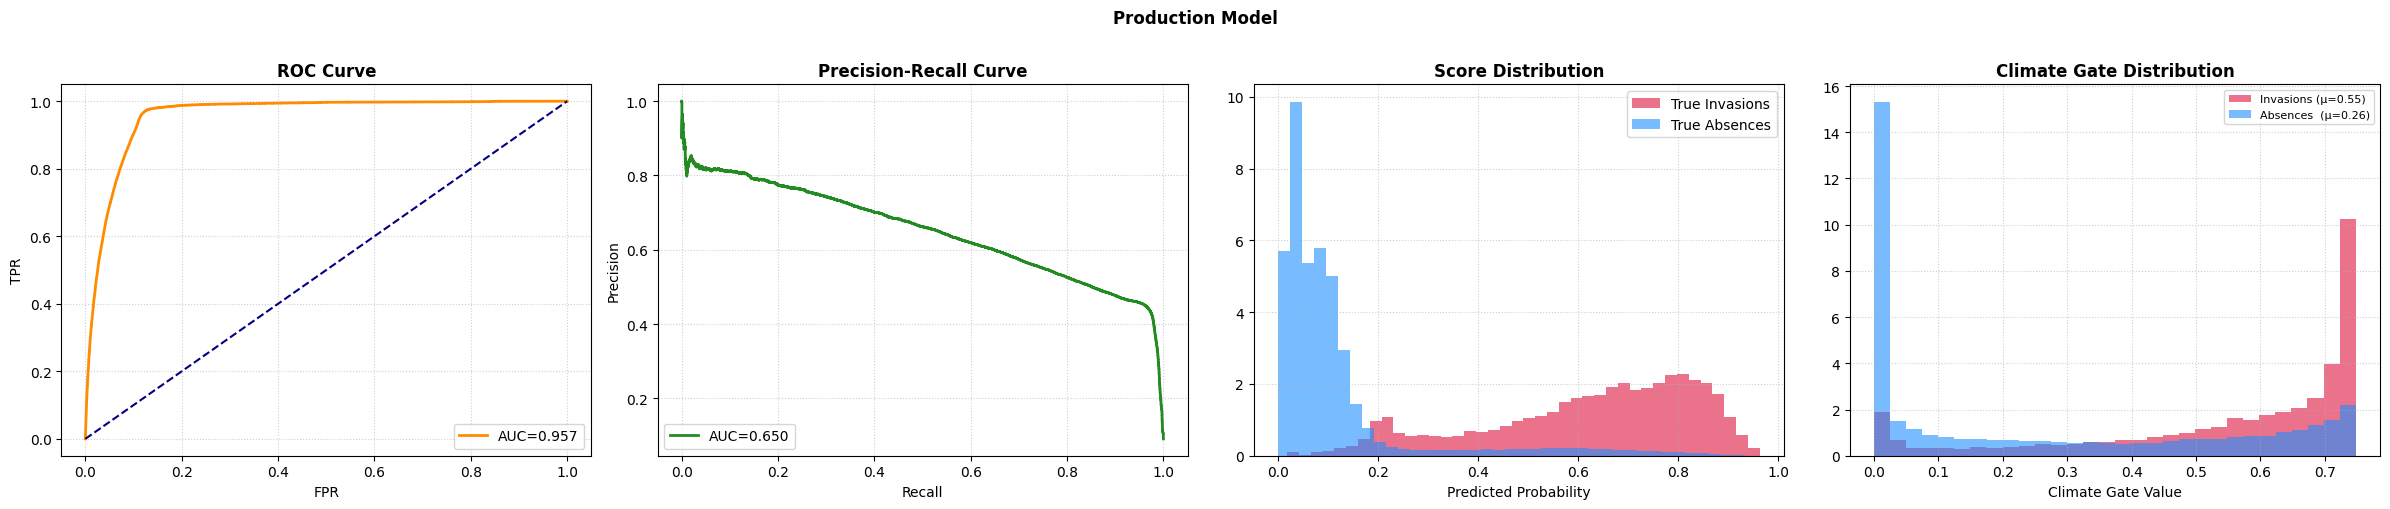

   📊 Saved to gnn_diagnostics_production_model.png


In [49]:
# ==============================================================================
# 12. EVALUATION DASHBOARD (4-panel)
# ==============================================================================
def plot_evaluation_dashboard(result, title='GNN Evaluation'):
    """Renders ROC, PR, score distribution, and gate calibration panels."""
    pos_probs  = result['pos_probs']
    neg_probs  = result['neg_probs']
    pos_gate   = result['pos_gate']
    neg_gate   = result['neg_gate']
    fpr, tpr   = result['fpr'], result['tpr']
    precision  = result['precision']
    recall     = result['recall']
    roc_auc    = result['roc_auc']
    pr_auc     = result['pr_auc']

    print(f"\n📊 {title}")
    print("=" * 60)
    print(f"   ROC-AUC : {roc_auc:.4f}  (Target > 0.80)")
    print(f"   PR-AUC  : {pr_auc:.4f}  (Target > 0.80)")
    print(f"   Pos mean: {pos_probs.mean():.4f} | Neg mean: {neg_probs.mean():.4f}")
    gate_sep = pos_gate.mean() - neg_gate.mean()
    marker   = "✅" if gate_sep > 0.05 else ("⚠️ " if gate_sep > 0 else "❌")
    print(f"   Gate sep: {gate_sep:+.3f} {marker}")
    print("=" * 60)

    fig, axes = plt.subplots(1, 4, figsize=(24, 5))

    axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC={roc_auc:.3f}')
    axes[0].plot([0,1],[0,1], 'navy', lw=1.5, linestyle='--')
    axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
    axes[0].set_title('ROC Curve', fontweight='bold')
    axes[0].legend(loc='lower right'); axes[0].grid(True, linestyle=':', alpha=0.6)

    axes[1].plot(recall, precision, color='forestgreen', lw=2, label=f'AUC={pr_auc:.3f}')
    axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
    axes[1].set_title('Precision-Recall Curve', fontweight='bold')
    axes[1].legend(loc='lower left'); axes[1].grid(True, linestyle=':', alpha=0.6)

    axes[2].hist(pos_probs, bins=40, alpha=0.6, color='crimson',
                 density=True, label='True Invasions')
    axes[2].hist(neg_probs, bins=40, alpha=0.6, color='dodgerblue',
                 density=True, label='True Absences')
    axes[2].set_xlabel('Predicted Probability')
    axes[2].set_title('Score Distribution', fontweight='bold')
    axes[2].legend(); axes[2].grid(True, linestyle=':', alpha=0.6)

    axes[3].hist(pos_gate, bins=30, alpha=0.6, color='crimson',
                 density=True, label=f'Invasions (μ={pos_gate.mean():.2f})')
    axes[3].hist(neg_gate, bins=30, alpha=0.6, color='dodgerblue',
                 density=True, label=f'Absences  (μ={neg_gate.mean():.2f})')
    axes[3].set_xlabel('Climate Gate Value')
    axes[3].set_title('Climate Gate Distribution', fontweight='bold')
    axes[3].legend(fontsize=8); axes[3].grid(True, linestyle=':', alpha=0.6)

    plt.suptitle(title, fontweight='bold', y=1.01)
    plt.tight_layout()
    fname = f"gnn_diagnostics_{title.replace(' ','_').lower()}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"   📊 Saved to {fname}")


# Plot production model evaluation
plot_evaluation_dashboard(prod_result, 'Production Model')

In [50]:
# ==============================================================================
# DIAGNOSTIC: confirm the PU / hard-negative label-noise hypothesis
# ==============================================================================
with torch.no_grad():
    # 1. How close are training positives to the "hard" negatives, in m-dist?
    pos_m_dist = ((sp_realized_mean[prod_train_sp] - co_climate_tensor[prod_train_co])
                  / sp_realized_std[prod_train_sp]).pow(2).sum(-1).sqrt().cpu().numpy()

    hard_neg_sp, hard_neg_co = sample_negative_edges_hard(
        prod_train_sp.size(0) * 5,
        set(zip(pos_sp.tolist(), pos_co.tolist())),
        sp_realized_mean, sp_realized_std)
    hard_m_dist = ((sp_realized_mean[hard_neg_sp] - co_climate_tensor[hard_neg_co])
                   / sp_realized_std[hard_neg_sp]).pow(2).sum(-1).sqrt().cpu().numpy()

print(f"Positive m-dist:     mean={pos_m_dist.mean():.3f}  median={np.median(pos_m_dist):.3f}")
print(f"Hard-negative m-dist: mean={hard_m_dist.mean():.3f}  median={np.median(hard_m_dist):.3f}")
# If these two are close to each other, hard negatives are near-indistinguishable
# from positives in climate space -> strong PU-noise signature.

# 2. How many hard negatives involve zero-signal (zero structural feature) species?
zero_signal_mask = (sp_features.sum(dim=1) == 0)
frac_zero_in_hard_neg = zero_signal_mask[hard_neg_sp.cpu()].float().mean().item()
frac_zero_in_all_sp   = zero_signal_mask.float().mean().item()
print(f"Fraction of hard negatives that are zero-signal species: {frac_zero_in_hard_neg:.3f}")
print(f"Fraction of ALL species that are zero-signal: {frac_zero_in_all_sp:.3f}")

# 3. Tie/near-tie check in production val scores (hump-curve signature)
from collections import Counter
rounded = np.round(np.concatenate([prod_result['pos_probs'], prod_result['neg_probs']]), 3)
dupes = Counter(rounded)
top_ties = dupes.most_common(5)
print(f"Most common rounded probability values (val pos+neg combined): {top_ties}")

Positive m-dist:     mean=2.268  median=2.106
Hard-negative m-dist: mean=3.367  median=3.319
Fraction of hard negatives that are zero-signal species: 0.000
Fraction of ALL species that are zero-signal: 0.009
Most common rounded probability values (val pos+neg combined): [(np.float32(0.022), 2872), (np.float32(0.023), 2758), (np.float32(0.024), 2531), (np.float32(0.021), 2387), (np.float32(0.028), 2372)]


In [22]:
# ==============================================================================
# 12b. EXPORT STATIC HORIZON-SCANNING ARTIFACT
#
#    Saves everything needed to run execute_gnn_horizon_scan() later without
#    rerunning training. Note: EVERYTHING is moved to CPU before saving,
#    regardless of which device strategy Section 7 uses (fully-on-DEVICE or
#    CPU-resident lookups) — this is what caused your original crash, since
#    the previous export saved a mix of DEVICE and CPU tensors and reloading
#    on a machine/session with different GPU availability produced exactly
#    the "found at least two devices" error.
#
#    CHANGES FROM PREVIOUS VERSION:
#    - Added 'num_species' and 'has_any_signal' to the export dict. The
#      static scanner needs both: num_species to know how many candidates
#      exist without depending on any live variable, and has_any_signal to
#      exclude zero-evidence species (no structural degree, no presence
#      records) from the ranked output — these were the species producing
#      nonsensical, near-identical top scores in earlier inference runs.
#    - bio_opp_mat replaced with pos_opp_mat + neg_opp_mat (valence split).
# ==============================================================================
print("💾 Exporting static horizon scanning static artifact...")

encoder.eval(); predictor.eval(); trade_encoder.eval(); country_ae.eval()
with torch.no_grad():
    final_sp_emb = encoder(sp_x_dict, train_edge_index_dict)['species'].cpu()
    final_co_lat = country_ae.encode(co_climate_tensor).cpu()

export_dict = {
    'predictor_state':     predictor.state_dict(),
    'trade_encoder_state': trade_encoder.state_dict(),
    'country_ae_state':    country_ae.state_dict(),

    # Precomputed tensors — all explicitly moved to CPU so the artifact
    # loads correctly on any machine, GPU or not, later
    'sp_emb':            final_sp_emb,
    'co_latent':         final_co_lat,
    'co_climate_tensor': co_climate_tensor.cpu(),
    'sp_realized_mean':  sp_realized_mean.cpu(),
    'sp_realized_std':   sp_realized_std.cpu(),
    'gate_sigma':        GATE_SIGMA,

    # NEW — needed by the static scanner
    'num_species':     num_species,
    'has_any_signal':  has_any_signal.cpu(),

    # Lookup tensors needed by compute_trade_latent / biotic_opportunity_score
    # at inference time. FIX: previously this used `if 'X_cpu' in dir() else X`
    # to guess between a "CPU-resident" and "fully-on-DEVICE" strategy. But
    # Section 7 only ever implements the fully-on-DEVICE strategy in this
    # notebook — the `_cpu` names are never assigned anywhere, so `dir()`
    # was really just checking "did some earlier/other cell in this kernel
    # session happen to leave a stale variable with this name lying around".
    # If it had (e.g. from testing an alternate Section 7 strategy without
    # restarting the kernel), this checkpoint would silently save THOSE
    # stale tensors instead of the ones the model actually just trained on —
    # producing a static model whose predictions don't match live training.
    # Always reference the live, just-trained-against tensors directly.
    'trade_channels_tensor': trade_channels_tensor.cpu(),
    'co_trade_import': co_trade_import.cpu(),
    'presence_mat': presence_mat.cpu(),
    'pos_opp_mat': pos_opp_mat.cpu(),
    'neg_opp_mat': neg_opp_mat.cpu(),

    # Index maps needed to interpret species/country IDs at inference time
    'sp_to_idx': sp_to_idx, 'idx_to_sp': idx_to_sp,
    'co_to_idx': co_to_idx, 'idx_to_co': idx_to_co,
    'id_to_name': id_to_name,
}

torch.save(export_dict, 'horizon_scan_static.pt')
print("   ✅ Saved to horizon_scan_static.pt")

💾 Exporting static horizon scanning static artifact...
   ✅ Saved to horizon_scan_static.pt


In [51]:
# ==============================================================================
# 13. INFERENCE — HORIZON SCANNING
# ==============================================================================
INFERENCE_CHUNK = 2048

def execute_gnn_horizon_scan(target_country_name: str, top_n: int = 500) -> pd.DataFrame:
    """
    Score all species not recorded in target_country_name and return top_n
    ranked by invasion probability.
    All tensors on DEVICE; no device moves inside this function.
    """
    if target_country_name not in co_to_idx:
        raise ValueError(f"'{target_country_name}' not found in spatial index.")

    encoder.eval(); predictor.eval(); trade_encoder.eval(); country_ae.eval()

    with torch.no_grad():
        co_lat = country_ae.encode(co_climate_tensor)
        sp_emb = encoder(sp_x_dict, train_edge_index_dict)['species']

    co_idx = co_to_idx[target_country_name]

    # Exclude species already recorded in SINAS for this country
    local_sp_ids     = df_sinas[df_sinas[country_col] == target_country_name]['gbif_id'].unique()
    local_sp_indices = {sp_to_idx[s] for s in local_sp_ids if s in sp_to_idx}
    candidate_indices = [i for i in range(num_species) if i not in local_sp_indices]

    candidate_tensor = torch.tensor(candidate_indices, dtype=torch.long, device=DEVICE)
    country_tensor   = torch.full((len(candidate_indices),), co_idx,
                                  dtype=torch.long, device=DEVICE)

    scores = []
    with torch.no_grad():
        for i in range(0, len(candidate_indices), INFERENCE_CHUNK):
            chunk_sp  = candidate_tensor[i:i + INFERENCE_CHUNK]
            chunk_co  = country_tensor[i:i + INFERENCE_CHUNK]
            trade_lat = compute_trade_latent(chunk_sp, chunk_co, trade_encoder)
            chunk_bio = biotic_opportunity_score(chunk_sp, chunk_co)
            chunk_logits, _ = predictor(
                sp_emb, co_lat, chunk_sp, chunk_co,
                sp_realized_mean, sp_realized_std,
                co_climate_tensor, trade_lat, bio_opp=chunk_bio)
            scores.append(torch.sigmoid(chunk_logits))

    probs = torch.cat(scores).cpu().numpy()

    df_scan = (
        pd.DataFrame([{
            'gbif_id':                  idx_to_sp[idx],
            'taxon_name':               id_to_name.get(idx_to_sp[idx],
                                                        f"GBIF:{idx_to_sp[idx]}"),
            'gnn_invasion_probability': float(p),
        } for idx, p in zip(candidate_indices, probs)])
        .sort_values('gnn_invasion_probability', ascending=False)
        .reset_index(drop=True)
        .head(top_n)
    )
    print(f"✅ GNN scan complete — {len(df_scan)} candidates ranked.")
    return df_scan

In [52]:
# ==============================================================================
# 14. GBIF VALIDATION
# ==============================================================================
def validate_horizon_threats_gbif(
    risk_df: pd.DataFrame,
    gbif_country_code: str,
    species_to_validate: int = 100,
    sleep_time: float = 0.2,
) -> pd.DataFrame:
    """
    Validates GNN predictions against live GBIF occurrence counts.
    Keeps only species with zero confirmed occurrences in the target country.
    """
    if not gbif_country_code:
        print("⚠️ No GBIF country code provided. Skipping validation.")
        return risk_df.head(species_to_validate)

    print(f"🔍 Validating via GBIF for '{gbif_country_code}'...")
    validated_records = []
    api_calls_made = 0; discarded_present = 0; errors_hit = 0

    with tqdm(total=species_to_validate, desc="Verified absent threats",
              unit="species") as pbar:
        for _, row in risk_df.iterrows():
            if len(validated_records) >= species_to_validate:
                print(f"\n🎯 Top {species_to_validate} verified threats secured.")
                break

            if api_calls_made > 0:
                time.sleep(sleep_time)
            api_calls_made += 1

            taxon_key    = int(row['gbif_id'])
            current_name = str(row['taxon_name'])

            try:
                if current_name.startswith("GBIF:"):
                    resolved_name = (gbif_species.name_usage(key=taxon_key)
                                     .get('scientificName',
                                          f"Unresolved ID: {taxon_key}"))
                else:
                    resolved_name = current_name

                occurrence_count = (
                    occurrences.search(taxonKey=taxon_key,
                                       country=gbif_country_code, limit=0)
                    .get('count', 0))

                if occurrence_count == 0:
                    new_row = row.to_dict()
                    new_row['taxon_name']            = resolved_name
                    new_row['gbif_matched_name']     = resolved_name
                    new_row['gbif_occurrence_count'] = occurrence_count
                    new_row['gbif_taxon_key']        = taxon_key
                    validated_records.append(new_row)
                    pbar.update(1)
                else:
                    discarded_present += 1

                pbar.set_postfix({'API calls': api_calls_made,
                                  'Already present': discarded_present,
                                  'Errors': errors_hit})

            except Exception as e:
                errors_hit += 1
                time.sleep(sleep_time * 5)
                err_row = row.to_dict()
                err_row['gbif_matched_name']     = f"FETCH ERROR: {str(e)[:40]}"
                err_row['gbif_occurrence_count'] = -1
                err_row['gbif_taxon_key']        = taxon_key
                validated_records.append(err_row)
                pbar.update(1)

    return pd.DataFrame(validated_records).reset_index(drop=True)

In [53]:
# ==============================================================================
# RUN — BELGIUM
# ==============================================================================
belgium_gnn_rankings = execute_gnn_horizon_scan('Belgium', top_n=500)

belgium_validated = validate_horizon_threats_gbif(
    belgium_gnn_rankings,
    gbif_country_code='BE',
    species_to_validate=100,
    sleep_time=1,
)

belgium_validated.head(20)

✅ GNN scan complete — 500 candidates ranked.
🔍 Validating via GBIF for 'BE'...


Verified absent threats:   0%|          | 0/100 [00:00<?, ?species/s]


🎯 Top 100 verified threats secured.


,gbif_id,taxon_name,gnn_invasion_probability,gbif_matched_name,gbif_occurrence_count,gbif_taxon_key
0,2991373,Rubus parvifolius,0.943450,Rubus parvifolius,0,2991373
1,3112887,Cirsium japonicum,0.940621,Cirsium japonicum,0,3112887
2,3134183,Delairea odorata,0.940213,Delairea odorata,0,3134183
3,3048882,Cakile edentula,0.938958,Cakile edentula,0,3048882
4,2704414,Sorghastrum nutans,0.935044,Sorghastrum nutans,0,2704414
5,2990646,Rubus ursinus,0.926087,Rubus ursinus,0,2990646
6,2999072,Rubus cochinchinensis,0.926037,Rubus cochinchinensis,0,2999072
7,3021120,Prunus salicina,0.923701,Prunus salicina,0,3021120
8,3119144,Helianthus angustifolius,0.923342,Helianthus angustifolius,0,3119144
9,3087173,Ratibida columnifera,0.922495,Ratibida columnifera,0,3087173


In [54]:
#Attribution of prediction workflow (definitions)

def build_live_bundle(
    encoder, predictor, trade_encoder, country_ae,
    sp_x_dict, train_edge_index_dict,
    co_climate_tensor, sp_realized_mean, sp_realized_std,
    trade_channels_tensor, co_trade_import, presence_mat, pos_opp_mat, neg_opp_mat,
    sp_to_idx, co_to_idx,
):
    """
    Builds a (predictor, trade_encoder, bundle) tuple from whatever's
    currently live in the notebook's namespace — mirrors load_static_scanner()'s
    return shape exactly, so explain_prediction()/print_explanation() work
    unchanged on either. Doesn't move anything to a different device or
    mutate any module's .eval()/.train() state permanently — computation
    happens wherever your live tensors already live (GPU or CPU).
    """
    was_training = encoder.training
    encoder.eval(); predictor.eval(); trade_encoder.eval(); country_ae.eval()
    with torch.no_grad():
        sp_emb    = encoder(sp_x_dict, train_edge_index_dict)['species']
        co_latent = country_ae.encode(co_climate_tensor)
    if was_training:
        encoder.train()   # restore, in case you're calling this mid-training-loop

    bundle = {
        'sp_emb': sp_emb, 'co_latent': co_latent,
        'co_climate_tensor': co_climate_tensor,
        'sp_realized_mean': sp_realized_mean, 'sp_realized_std': sp_realized_std,
        'trade_channels_tensor': trade_channels_tensor,
        'co_trade_import': co_trade_import,
        'presence_mat': presence_mat, 'pos_opp_mat': pos_opp_mat, 'neg_opp_mat': neg_opp_mat,
        'sp_to_idx': sp_to_idx, 'co_to_idx': co_to_idx,
    }
    return predictor, trade_encoder, bundle

def _forward_from_leaves(predictor, trade_encoder, realized_mean, realized_std,
                          climate_t, imp_v, exp_v, bio, spe, col):
    """Re-implements NicheMatchingPredictor.forward but takes each semantically-named
    input as an explicit leaf tensor, and (unlike training) does NOT detach the
    climate_gate input — for explanation we want gradients to flow through every
    real computational path, including the climate->gate->topology path."""
    z_diff = (realized_mean - climate_t) / realized_std
    abs_z  = z_diff.abs()
    m_dist = z_diff.pow(2).sum(dim=-1, keepdim=True).sqrt()
    gate   = predictor.climate_gate(torch.cat([m_dist, z_diff.pow(2)], dim=-1))  # no .detach()

    topo_out  = predictor.topo_stream(torch.cat([spe, col], dim=-1)) * gate
    niche_out = predictor.niche_stream(torch.cat([realized_mean, climate_t, abs_z], dim=-1))
    suit_out  = predictor.suitability_stream(torch.cat([realized_mean, climate_t], dim=-1))
    trade_latent = trade_encoder(imp_v, exp_v)
    trade_out = predictor.trade_proj(trade_latent)
    bio_out   = predictor.bio_opp_proj(bio)

    logits = predictor.classifier(
        torch.cat([topo_out, niche_out, suit_out, trade_out, bio_out], dim=-1)
    ).squeeze(-1)
    return logits


def explain_prediction(
    scanner_data: tuple,          # (predictor, trade_encoder, ckpt) from load_static_scanner
    gbif_id: int,
    target_country: str,
    climate_feature_names: list,  # e.g. list(df_climate.columns.drop('location'))
    trade_channel_names: list,    # e.g. list(ECOLOGICAL_TRADE_MAPPING.keys())
    n_steps: int = 50,
    baseline: str = "mean",       # "mean" = compare vs. an average country/species; "zero" = compare vs. no signal at all
):
    """
    Integrated Gradients attribution for one (species, country) pair.
    Returns per-feature contributions to the pre-sigmoid logit, broken down
    into: each climate axis, each trade channel (import + export separately),
    biotic opportunity (positive and negative valence, separately), and the
    two "relational" (GNN / country-latent) blocks.

    Attributions sum (approximately) to actual_logit - baseline_logit — this
    is the IG "completeness" property, and the returned completeness_gap
    tells you exactly how good that approximation was (should be small;
    increase n_steps if it isn't).
    """
    predictor, trade_encoder, ckpt = scanner_data
    device = ckpt["sp_emb"].device

    sp_idx = torch.as_tensor([ckpt["sp_to_idx"][gbif_id]], device=device)
    co_idx = torch.as_tensor([ckpt["co_to_idx"][target_country]], device=device)

    # ---- Assemble the actual leaf values for this pair ----
    realized_mean = ckpt["sp_realized_mean"][sp_idx].detach()
    realized_std  = ckpt["sp_realized_std"][sp_idx].detach()
    target_climate = ckpt["co_climate_tensor"][co_idx].detach()

    trade_to_dest = ckpt["trade_channels_tensor"][:, :, co_idx].permute(2, 0, 1)
    native_mask   = ckpt["presence_mat"][sp_idx].unsqueeze(1)
    export_vec = ((trade_to_dest * native_mask).sum(dim=2) /
                  native_mask.sum(dim=2).clamp(min=1)).detach()
    import_vec = ckpt["co_trade_import"][co_idx].detach()

    pos_opp = ckpt["pos_opp_mat"][sp_idx, co_idx].detach()
    neg_opp = ckpt["neg_opp_mat"][sp_idx, co_idx].detach()
    bio_opp = torch.stack([pos_opp, neg_opp], dim=-1)   # (1, 2)

    sp_e = ckpt["sp_emb"][sp_idx].detach()
    co_l = ckpt["co_latent"][co_idx].detach()

    actual  = [target_climate, import_vec, export_vec, bio_opp, sp_e, co_l]
    names   = ["climate", "trade_import", "trade_export", "bio_opp", "rel_species", "rel_country"]

    # ---- Baseline: "what if this pair looked like an average pair?" ----
    if baseline == "zero":
        base = [torch.zeros_like(t) for t in actual]
    elif baseline == "mean":
        base = [
            ckpt["co_climate_tensor"].mean(dim=0, keepdim=True),
            ckpt["co_trade_import"].mean(dim=0, keepdim=True),
            torch.zeros_like(export_vec),   # "no export exposure at all" is the natural zero-point for trade
            torch.zeros_like(bio_opp),      # "no biotic opportunity at all"
            ckpt["sp_emb"].mean(dim=0, keepdim=True),
            ckpt["co_latent"].mean(dim=0, keepdim=True),
        ]
    else:
        raise ValueError("baseline must be 'zero' or 'mean'")

    # ---- Integrated Gradients: average gradient along the straight-line path
    #      from baseline to actual, times (actual - baseline) ----
    grads_accum = [torch.zeros_like(t) for t in actual]
    for step in range(1, n_steps + 1):
        alpha = step / n_steps
        interp = [(b + alpha * (a - b)).clone().requires_grad_(True)
                  for a, b in zip(actual, base)]
        logit = _forward_from_leaves(predictor, trade_encoder, realized_mean, realized_std, *interp)
        grads = torch.autograd.grad(logit, interp)
        for acc, g in zip(grads_accum, grads):
            acc += g

    attributions = {}
    for name, g, a, b in zip(names, grads_accum, actual, base):
        attributions[name] = ((g / n_steps) * (a - b)).squeeze(0).detach().cpu()

    with torch.no_grad():
        actual_logit   = _forward_from_leaves(predictor, trade_encoder, realized_mean, realized_std, *actual).item()
        baseline_logit = _forward_from_leaves(predictor, trade_encoder, realized_mean, realized_std, *base).item()

    # ---- Expand into named, human-readable features ----
    result = {}
    for i, fname in enumerate(climate_feature_names):
        result[f"climate: {fname}"] = attributions["climate"][i].item()
    for i, cname in enumerate(trade_channel_names):
        result[f"trade import: {cname}"] = attributions["trade_import"][i].item()
        result[f"trade export: {cname}"] = attributions["trade_export"][i].item()
    result["biotic opportunity (positive: resource/mutualism)"] = attributions["bio_opp"][0].item()
    result["biotic opportunity (negative: enemy/competition)"]  = attributions["bio_opp"][1].item()
    result["relational ecology (species graph embedding)"] = attributions["rel_species"].sum().item()
    result["relational ecology (country climate latent)"]  = attributions["rel_country"].sum().item()

    return {
        "attributions": dict(sorted(result.items(), key=lambda kv: -abs(kv[1]))),
        "baseline_logit": baseline_logit,
        "actual_logit": actual_logit,
        "predicted_prob": torch.sigmoid(torch.tensor(actual_logit)).item(),
        "baseline_prob": torch.sigmoid(torch.tensor(baseline_logit)).item(),
        "completeness_gap": (actual_logit - baseline_logit) - sum(result.values()),
    }


def print_explanation(explanation, top_k=12):
    print(f"Predicted probability: {explanation['predicted_prob']:.3f} "
          f"(baseline: {explanation['baseline_prob']:.3f})")
    print(f"Completeness check (should be near 0): {explanation['completeness_gap']:+.4f}\n")
    print(f"{'Feature':45s} {'Attribution (logit units)':>25s}")
    print("-" * 72)
    for name, val in list(explanation["attributions"].items())[:top_k]:
        bar = "█" * int(min(abs(val) * 8, 30))
        sign = "+" if val >= 0 else "-"
        print(f"{name:45s} {val:+8.4f}  {sign}{bar}")

In [55]:
# On a machine with the trained objects still live in memory (right after
# cell 16, or anywhere later in the same kernel session):
live_scanner_data = build_live_bundle(
    encoder, predictor, trade_encoder, country_ae,
    sp_x_dict, train_edge_index_dict,
    co_climate_tensor, sp_realized_mean, sp_realized_std,
    trade_channels_tensor, co_trade_import, presence_mat, pos_opp_mat, neg_opp_mat,
    sp_to_idx, co_to_idx,
)

CLIMATE_FEATURE_NAMES = list(df_climate.columns.drop(country_col))   # the 7 climate variables, in the same order used to build co_climate_tensor
TRADE_CHANNEL_NAMES   = list(ECOLOGICAL_TRADE_MAPPING.keys())        # ['flora_and_timber', 'aquatic_fauna', ...]

# Identical downstream call either way:
explanation = explain_prediction(
    live_scanner_data,        # or static_scanner_data
    gbif_id=3112887,
    target_country="Belgium",
    climate_feature_names=CLIMATE_FEATURE_NAMES,
    trade_channel_names=TRADE_CHANNEL_NAMES,
)
print_explanation(explanation)

Predicted probability: 0.941 (baseline: 0.030)
Completeness check (should be near 0): +0.0204

Feature                                       Attribution (logit units)
------------------------------------------------------------------------
relational ecology (species graph embedding)   +5.8520  +██████████████████████████████
trade export: agri_hitchhikers                 +0.1224  +
trade export: microbial_risk                   +0.1123  +
trade export: aquatic_fauna                    +0.0645  +
climate: precipitation                         -0.0487  -
climate: latitude                              +0.0308  +
trade export: flora_and_timber                 +0.0283  +
climate: mean_temperature                      +0.0278  +
relational ecology (country climate latent)    +0.0239  +
biotic opportunity (negative: enemy/competition)  +0.0113  +
trade import: flora_and_timber                 +0.0086  +
trade export: terrestrial_pets                 +0.0070  +


In [56]:
import numpy as np

shares = []
for gbif_id in belgium_gnn_rankings['gbif_id'].sample(20, random_state=1):
    exp = explain_prediction(live_scanner_data, gbif_id=gbif_id, target_country='Belgium',
                              climate_feature_names=CLIMATE_FEATURE_NAMES,
                              trade_channel_names=TRADE_CHANNEL_NAMES)
    total = exp['actual_logit'] - exp['baseline_logit']
    topo  = exp['attributions']['relational ecology (species graph embedding)']
    shares.append(topo / total if total != 0 else float('nan'))

print(f"Median topology share of logit swing: {np.nanmedian(shares):.1%}")
print(f"Range: {np.nanmin(shares):.1%} – {np.nanmax(shares):.1%}")

Median topology share of logit swing: 92.1%
Range: 90.8% – 98.0%


In [58]:
import torch

with torch.no_grad():
    gbif_id = 2498252   # swap in one of your actual top-ranked species
    sp_id = live_scanner_data... # however sp_emb/co_latent are indexed in your live bundle — sp_to_idx[gbif_id]
    similar_climate_countries = ['Belgium', 'Netherlands', 'Germany', 'France', 'United Kingdom']

    sp_e = sp_emb[sp_to_idx[gbif_id]].unsqueeze(0)
    outs = {}
    for c in similar_climate_countries:
        co_l = co_latent[co_to_idx[c]].unsqueeze(0)
        t_out = predictor.topo_stream(torch.cat([sp_e, co_l], dim=-1))
        outs[c] = t_out

    base = outs['Belgium']
    for c, v in outs.items():
        print(f"{c:15s} cos_sim to Belgium: {torch.cosine_similarity(base, v).item():.4f}  "
              f"norm: {v.norm().item():.4f}")

SyntaxError: invalid syntax (1836296240.py, line 5)

In [ ]:
#STATIC MODEL IMPORT WORKFLOW

import time

import pandas as pd
import torch
from pygbif import occurrences
from tqdm.auto import tqdm


def load_static_scanner(checkpoint_path: str):
    """Load the static checkpoint and re-create its trained models on CPU."""
    print("⏳ Loading static horizon scanner...")
    ckpt = torch.load(checkpoint_path, map_location="cpu", weights_only=False)

    required_keys = {
        "predictor_state", "trade_encoder_state",
        "sp_emb", "co_latent", "co_climate_tensor",
        "sp_realized_mean", "sp_realized_std",
        "trade_channels_tensor", "co_trade_import",
        "presence_mat", "pos_opp_mat", "neg_opp_mat",
        "num_species", "has_any_signal",
        "co_to_idx", "idx_to_sp", "id_to_name",
    }
    missing_keys = required_keys - set(ckpt.keys())
    if missing_keys:
        raise KeyError(f"Checkpoint is missing: {sorted(missing_keys)}")

    emb_dim = ckpt["sp_emb"].shape[1]
    co_latent_dim = ckpt["co_latent"].shape[1]
    n_co_features = ckpt["co_climate_tensor"].shape[1]
    num_channels = ckpt["trade_channels_tensor"].shape[0]

    # Exact layer names in TradePathwayEncoder from this notebook.
    trade_state = ckpt["trade_encoder_state"]
    trade_hidden_dim = trade_state["encoder.0.weight"].shape[0]
    trade_latent_dim = trade_state["encoder.3.weight"].shape[0]

    predictor = NicheMatchingPredictor(
        sp_dim=emb_dim,
        co_latent_dim=co_latent_dim,
        n_co_features=n_co_features,
        trade_latent_dim=trade_latent_dim,
    )
    trade_encoder = TradePathwayEncoder(
        num_channels=num_channels,
        latent_dim=trade_latent_dim,
        hidden_dim=trade_hidden_dim,
    )

    predictor.load_state_dict(ckpt["predictor_state"], strict=True)
    trade_encoder.load_state_dict(trade_state, strict=True)

    predictor.eval()
    trade_encoder.eval()

    print(
        f"✅ Scanner ready — {ckpt['num_species']:,} species, "
        f"{len(ckpt['co_to_idx']):,} countries."
    )
    return predictor, trade_encoder, ckpt


def verify_absent_from_gbif(
    ranked_df: pd.DataFrame,
    gbif_country_code: str,
    top_n: int,
    sleep_time: float = 0.2,
) -> pd.DataFrame:
    """
    Query live GBIF occurrence records and retain only species with zero records
    in the specified country.
    """
    verified_records = []
    api_calls = 0
    already_present = 0
    errors = 0

    print(f"🔍 Verifying candidates against live GBIF records for '{gbif_country_code}'...")

    with tqdm(
        total=top_n,
        desc="Verified absent threats",
        unit="species",
    ) as pbar:

        for _, row in ranked_df.iterrows():
            if len(verified_records) >= top_n:
                break

            if api_calls > 0:
                time.sleep(sleep_time)

            taxon_key = int(row["gbif_id"])
            api_calls += 1

            try:
                occurrence_count = occurrences.search(
                    taxonKey=taxon_key,
                    country=gbif_country_code,
                    limit=0,
                ).get("count", 0)

                if occurrence_count == 0:
                    verified_row = row.to_dict()
                    verified_row["gbif_taxon_key"] = taxon_key
                    verified_row["gbif_occurrence_count"] = 0
                    verified_row["gbif_verification"] = "verified_absent"

                    verified_records.append(verified_row)
                    pbar.update(1)
                else:
                    already_present += 1

                pbar.set_postfix(
                    api_calls=api_calls,
                    already_present=already_present,
                    errors=errors,
                )

            except Exception as exc:
                errors += 1
                pbar.set_postfix(
                    api_calls=api_calls,
                    already_present=already_present,
                    errors=errors,
                )
                print(f"\n⚠️ GBIF lookup failed for taxon {taxon_key}: {str(exc)[:120]}")

    print(
        f"✅ GBIF check complete — {len(verified_records)} verified absent threats; "
        f"{already_present} already present; {errors} errors."
    )

    return pd.DataFrame(verified_records).reset_index(drop=True)


def execute_rapid_scan(
    target_country: str,
    gbif_country_code: str,
    top_n: int,
    scanner_data: tuple,
    verification_pool_size: int | None = None,
    sleep_time: float = 0.2,
) -> pd.DataFrame:
    """
    Rank static-model candidates, then retain only live-GBIF-verified absent
    threats. `gbif_country_code` must be an ISO two-letter code, e.g. AU.
    """
    predictor, trade_encoder, ckpt = scanner_data

    if target_country not in ckpt["co_to_idx"]:
        raise ValueError(f"'{target_country}' not found in the checkpoint country index.")

    co_idx_val = ckpt["co_to_idx"][target_country]

    # Exclude species without evidence and species in the checkpoint's cached
    # GBIF-presence data for the target country.
    candidate_mask = (
        ckpt["has_any_signal"].bool()
        & ~ckpt["presence_mat"][:, co_idx_val].bool()
    )
    candidate_tensor = torch.where(candidate_mask)[0]

    if candidate_tensor.numel() == 0:
        raise ValueError(f"No eligible candidate species found for '{target_country}'.")

    country_tensor = torch.full(
        (candidate_tensor.numel(),),
        co_idx_val,
        dtype=torch.long,
    )

    scores = []
    chunk_size = 2048

    with torch.no_grad():
        for start in range(0, candidate_tensor.numel(), chunk_size):
            chunk_sp = candidate_tensor[start:start + chunk_size]
            chunk_co = country_tensor[start:start + chunk_size]

            # Dynamic trade routing, identical to the training-time calculation.
            trade_to_dest = (
                ckpt["trade_channels_tensor"][:, :, chunk_co]
                .permute(2, 0, 1)
            )
            native_mask = ckpt["presence_mat"][chunk_sp].unsqueeze(1)

            export_vec = (
                (trade_to_dest * native_mask).sum(dim=2)
                / native_mask.sum(dim=2).clamp(min=1)
            )
            import_vec = ckpt["co_trade_import"][chunk_co]
            trade_latent = trade_encoder(import_vec, export_vec)

            # Biotic opportunity was used in model training and is in the checkpoint.
            bio_opp = torch.stack([
                ckpt["pos_opp_mat"][chunk_sp, chunk_co],
                ckpt["neg_opp_mat"][chunk_sp, chunk_co],
            ], dim=-1)

            logits, _ = predictor(
                sp_emb=ckpt["sp_emb"],
                co_latent=ckpt["co_latent"],
                sp_idx=chunk_sp,
                co_idx=chunk_co,
                sp_realized_mean=ckpt["sp_realized_mean"],
                sp_realized_std=ckpt["sp_realized_std"],
                co_climate_tensor=ckpt["co_climate_tensor"],
                trade_latent=trade_latent,
                bio_opp=bio_opp,
            )
            scores.append(torch.sigmoid(logits))

    probabilities = torch.cat(scores).cpu().numpy()
    candidate_indices = candidate_tensor.tolist()

    ranked_df = (
        pd.DataFrame(
            {
                "gbif_id": [ckpt["idx_to_sp"][idx] for idx in candidate_indices],
                "taxon_name": [
                    ckpt["id_to_name"].get(
                        ckpt["idx_to_sp"][idx],
                        f"Unknown ID: {idx}",
                    )
                    for idx in candidate_indices
                ],
                "invasion_probability": probabilities,
            }
        )
        .sort_values("invasion_probability", ascending=False)
        .reset_index(drop=True)
    )

    # Check extra candidates because GBIF can reject some top-ranked candidates
    # as already present. Five times top_n is a reasonable default.
    if verification_pool_size is None:
        verification_pool_size = max(top_n * 5, 100)

    verification_pool = ranked_df.head(verification_pool_size)

    return verify_absent_from_gbif(
        ranked_df=verification_pool,
        gbif_country_code=gbif_country_code,
        top_n=top_n,
        sleep_time=sleep_time,
    )


# Australia = AU
scanner_data = load_static_scanner("horizon_scan_static.pt")

risk_df = execute_rapid_scan(
    target_country="Belgium",
    gbif_country_code="BE",
    top_n=100, #number retained after GBIF verification
    scanner_data=scanner_data,
    verification_pool_size=500, #number originally scanned
    sleep_time=0.2,
)

print(risk_df)

⏳ Loading static horizon scanner...
✅ Scanner ready — 167,357 species, 289 countries.
🔍 Verifying candidates against live GBIF records for 'BE'...


Verified absent threats:   0%|          | 0/100 [00:00<?, ?species/s]

✅ GBIF check complete — 100 verified absent threats; 1 already present; 0 errors.
    gbif_id           taxon_name  invasion_probability  gbif_taxon_key  \
0   3112887    Cirsium japonicum              0.959837         3112887   
1   2991373    Rubus parvifolius              0.943670         2991373   
2   3021120      Prunus salicina              0.940998         3021120   
3   3048882      Cakile edentula              0.936438         3048882   
4   3134183     Delairea odorata              0.934659         3134183   
..      ...                  ...                   ...             ...   
95  3189521  Hypericum frondosum              0.905595         3189521   
96  2992071    Rubus flagellaris              0.905458         2992071   
97  7274828      Acmispon glaber              0.905290         7274828   
98  5372629        Salix cordata              0.905280         5372629   
99  2888726     Sambucus cerulea              0.905200         2888726   

    gbif_occurrence_count gbi

In [ ]:
#actual attribution workflow (static scanner)

CLIMATE_FEATURE_NAMES = list(df_climate.columns.drop(country_col))   # the 7 climate variables, in the same order used to build co_climate_tensor
TRADE_CHANNEL_NAMES   = list(ECOLOGICAL_TRADE_MAPPING.keys())        # ['flora_and_timber', 'aquatic_fauna', ...]

scanner_data = load_static_scanner("horizon_scan_static.pt")

explanation = explain_prediction(
    scanner_data,
    gbif_id=2498252,          # any species GBIF id present in ckpt['sp_to_idx']
    target_country="Belgium",
    climate_feature_names=CLIMATE_FEATURE_NAMES,
    trade_channel_names=TRADE_CHANNEL_NAMES,
)
print_explanation(explanation)